# initial

In [7]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, r=28, b=8/3):
        self.s, self.r, self.b = s, r, b

    def X(self, x, y, s): return s * (y - x)
    def Y(self, x, y, z, r): return -x*z + r*x - y
    def Z(self, x, y, z, b): return x*y - b*z

    def RK4(self, x, y, z, s, r, b, dt):
        k1 = self.X(x, y, s)
        l1 = self.Y(x, y, z, r)
        m1 = self.Z(x, y, z, b)

        k2 = self.X(x + k1*dt/2, y + l1*dt/2, s)
        l2 = self.Y(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, r)
        m2 = self.Z(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, b)

        k3 = self.X(x + k2*dt/2, y + l2*dt/2, s)
        l3 = self.Y(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, r)
        m3 = self.Z(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, b)

        k4 = self.X(x + k3*dt, y + l3*dt, s)
        l4 = self.Y(x + k3*dt, y + l3*dt, z + m3*dt, r)
        m4 = self.Z(x + k3*dt, y + l3*dt, z + m3*dt, b)

        x += (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        y += (l1 + 2*l2 + 2*l3 + l4) * dt / 6
        z += (m1 + 2*m2 + 2*m3 + m4) * dt / 6
        return x, y, z

    def generate(self, dt, steps):
        x, y, z = 1, 1, 1
        x_list = [x]
        for _ in range(steps):
            x, y, z = self.RK4(x, y, z, self.s, self.r, self.b, dt)
            x_list.append(x)
        return np.array(x_list), None, None

# Generate data with alternating r values
print("Generating data...")
dt = 0.01
points_per_segment = 192000
skip = 1000
segments = []
change_indices = []
current_idx = 0

for i in range(100):
    r = 28.0 if i % 2 == 0 else 29.4
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Generating data...
Total points: 19200100, Changes at: [192001, 384002, 576003, 768004, 960005, 1152006, 1344007, 1536008, 1728009, 1920010, 2112011, 2304012, 2496013, 2688014, 2880015, 3072016, 3264017, 3456018, 3648019, 3840020, 4032021, 4224022, 4416023, 4608024, 4800025, 4992026, 5184027, 5376028, 5568029, 5760030, 5952031, 6144032, 6336033, 6528034, 6720035, 6912036, 7104037, 7296038, 7488039, 7680040, 7872041, 8064042, 8256043, 8448044, 8640045, 8832046, 9024047, 9216048, 9408049, 9600050, 9792051, 9984052, 10176053, 10368054, 10560055, 10752056, 10944057, 11136058, 11328059, 11520060, 11712061, 11904062, 12096063, 12288064, 12480065, 12672066, 12864067, 13056068, 13248069, 13440070, 13632071, 13824072, 14016073, 14208074, 14400075, 14592076, 14784077, 14976078, 15168079, 15360080, 15552081, 15744082, 15936083, 16128084, 16320085, 16512086, 16704087, 16896088, 17088089, 17280090, 17472091, 17664092, 17856093, 18048094, 18240095, 18432096, 18624097, 18816098, 19008099]


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from scipy.stats import linregress

# ============================================================
# LOCAL FEATURES (51-point window)
# ============================================================

half_window = 25
features = []
indices = []

for i in range(half_window, len(data) - half_window):

    window = data[i-half_window:i+half_window+1]

    f = {}

    f['std'] = np.std(window)
    f['rms'] = np.sqrt(np.mean(window**2))
    f['peak_to_peak'] = np.ptp(window)
    f['line_length'] = np.sum(np.abs(np.diff(window)))
    f['zero_crossing'] = np.sum(np.diff(np.sign(window)) != 0)

    diff1 = np.diff(window)
    diff2 = np.diff(diff1)

    if np.std(window) > 0:
        mobility = np.std(diff1) / np.std(window)
        complexity = (
            np.std(diff2) / np.std(diff1) / mobility
            if np.std(diff1) > 0 and mobility > 0 else 0
        )
    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    features.append(f)
    indices.append(i)

features_df = pd.DataFrame(features)

In [9]:
# ============================================================
# SCALE
# ============================================================

scaler = StandardScaler()
X_local = scaler.fit_transform(features_df)

# ============================================================
# SEQUENCE WINDOWS
# ============================================================

seq_len = 1000
stride = 50

X_seq = []
y_seq = []

change_indices = np.array(change_indices)

In [10]:
for start in range(0, len(X_local) - seq_len, stride):

    end = start + seq_len

    seq = X_local[start:end]

    # ----------------------------------------
    # aggregate sequence statistics
    # ----------------------------------------

    seq_features = []

    # mean/std over time for each feature
    seq_features.extend(seq.mean(axis=0))
    seq_features.extend(seq.std(axis=0))

    # ----------------------------------------
    # contrast features
    # ----------------------------------------

    left = seq[:seq_len//2]
    right = seq[seq_len//2:]

    contrast = right.mean(axis=0) - left.mean(axis=0)
    seq_features.extend(contrast)

    # ----------------------------------------
    # temporal slopes
    # ----------------------------------------

    t = np.arange(seq_len)

    for j in range(seq.shape[1]):
        slope = linregress(t, seq[:, j]).slope
        seq_features.append(slope)

    X_seq.append(seq_features)

    # ----------------------------------------
    # label
    # ----------------------------------------

    center = start + seq_len // 2

    label = np.any(np.abs(change_indices - center) < 300)

    y_seq.append(int(label))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape, y_seq.shape)

(383981, 28) (383981,)


## clf

In [11]:
split = int(0.7 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    114835
           1       0.96      1.00      0.98       360

    accuracy                           1.00    115195
   macro avg       0.98      1.00      0.99    115195
weighted avg       1.00      1.00      1.00    115195



# cool beautiful feature explo

1. Covariance Matrix Estimation

The covariance matrix is estimated from all feature vectors:

$$
\Sigma = \frac{1}{n-1} \sum_{i=1}^{n} (\mathbf{f}_i - \mathbf{\bar{f}})(\mathbf{f}_i - \mathbf{\bar{f}})^T
$$

where:
- $\mathbf{f}_i \in \mathbb{R}^p$ are the feature vectors
- $\mathbf{\bar{f}} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{f}_i$ is the mean feature vector
- $n$ is the number of feature vectors
- $p$ is the number of features

2. Regularization

To ensure invertibility, Tikhonov regularization is applied:

$$
\Sigma_{\text{reg}} = \Sigma + \lambda I_p
$$

where:
- $\lambda = 10^{-6}$ (regularization parameter)
- $I_p \in \mathbb{R}^{p \times p}$ is the identity matrix

3. Inverse Calculation

The pseudo-inverse of the regularized covariance matrix is computed:

$$
\Sigma_{\text{reg}}^{-1} = \text{pinv}(\Sigma_{\text{reg}})
$$

Since $\Sigma_{\text{reg}}$ is positive definite, this equals the true inverse.

4. Mahalanobis Distance

For each sliding window pair at time $t$, the Mahalanobis distance is:

$$
d_M(t) = \sqrt{(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t))^T \Sigma_{\text{reg}}^{-1} (\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t))}
$$

where:
- $\mathbf{x}_{\text{left}}(t)$ = features from window $[t-WINDOW, t]$
- $\mathbf{x}_{\text{right}}(t)$ = features from window $[t, t+WINDOW]$

5. Complete Formula

Substituting everything:

$$
\boxed{d_M(t) = \sqrt{\left(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t)\right)^T \left( \frac{1}{n-1}\sum_{i=1}^{n} (\mathbf{f}_i - \mathbf{\bar{f}})(\mathbf{f}_i - \mathbf{\bar{f}})^T + 10^{-6} I_p \right)^{-1} \left(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t)\right)}}
$$

# 50-stride left-right divergence with window of 100

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

# ============================================================
# PARAMETERS
# ============================================================

WINDOW = 1000
STEP = 50

# regime change timestamps
change_points = np.array(change_indices)

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

## features

In [13]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [14]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov)

# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

### overview

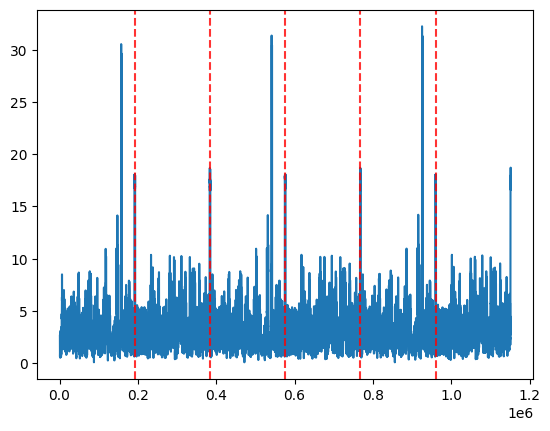

In [35]:
plt.plot(
    timestamps[timestamps < 1152006],
    scores_mahal[timestamps < 1152006],
)

for cp in change_points[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

### first 5 plot +-500 around the regime change

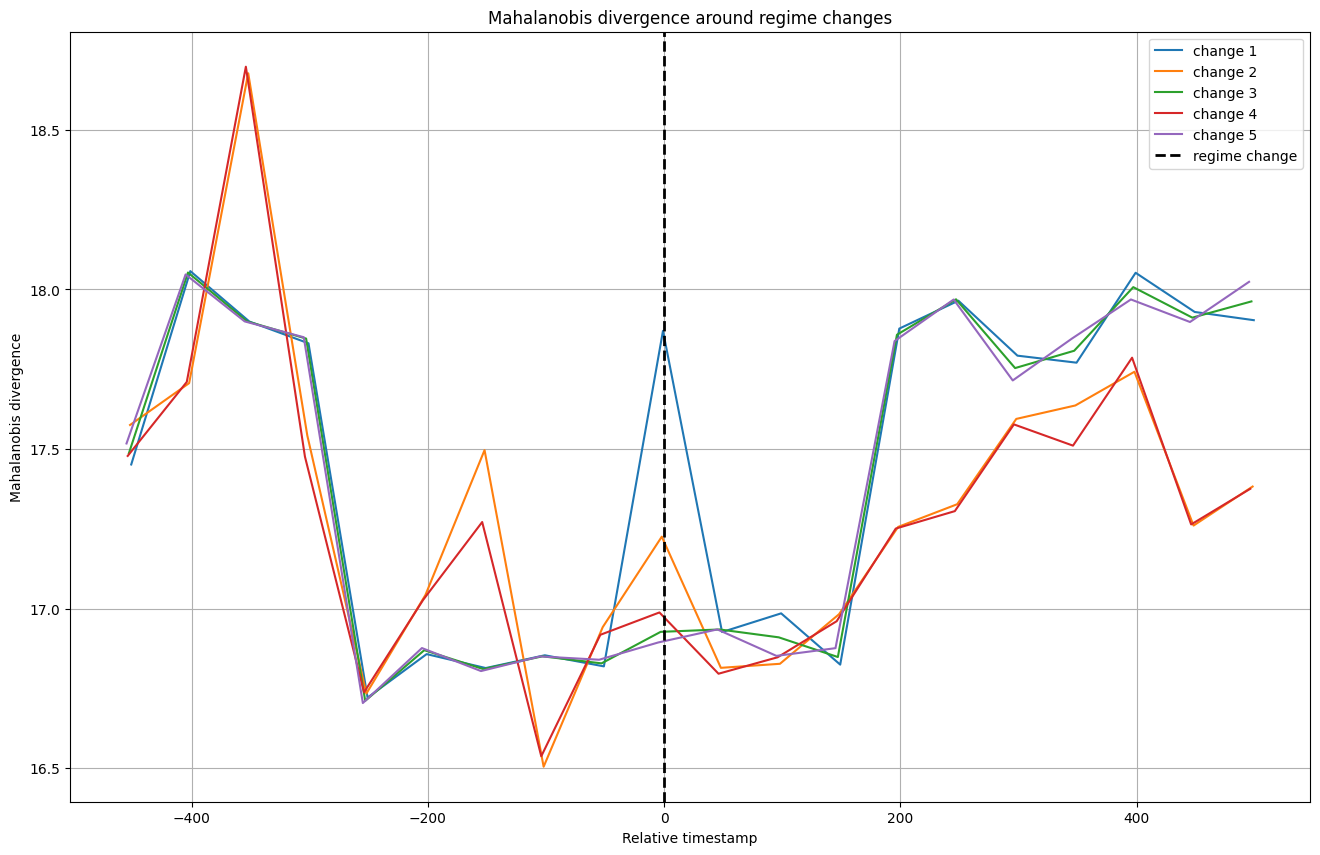

In [36]:

selected_changes = change_points[:5]

half_range = 500

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean around +- 500 regime cahnge

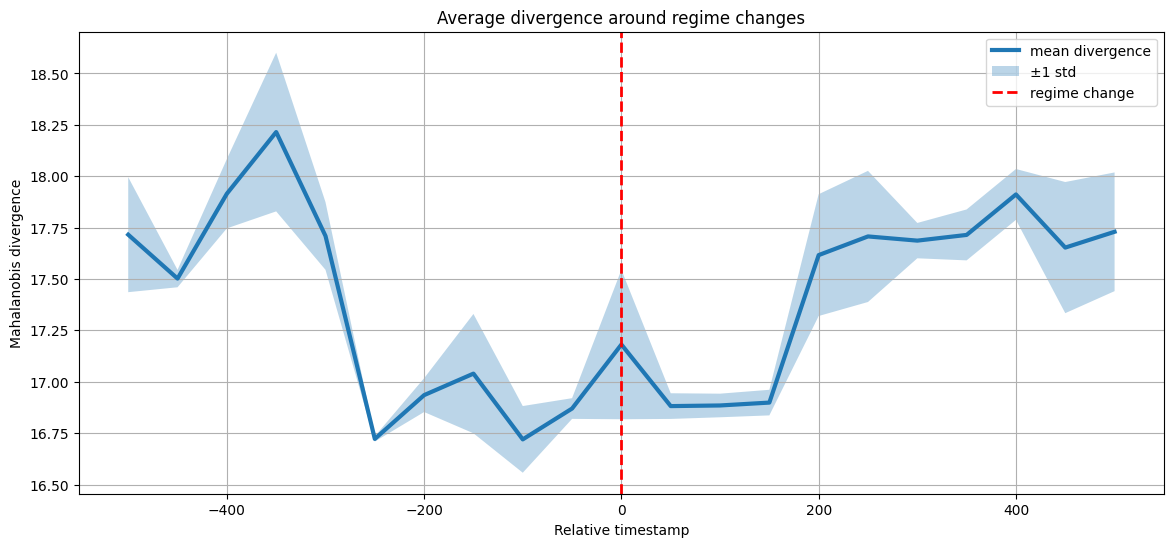

In [37]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### 5 plots around +- 5000

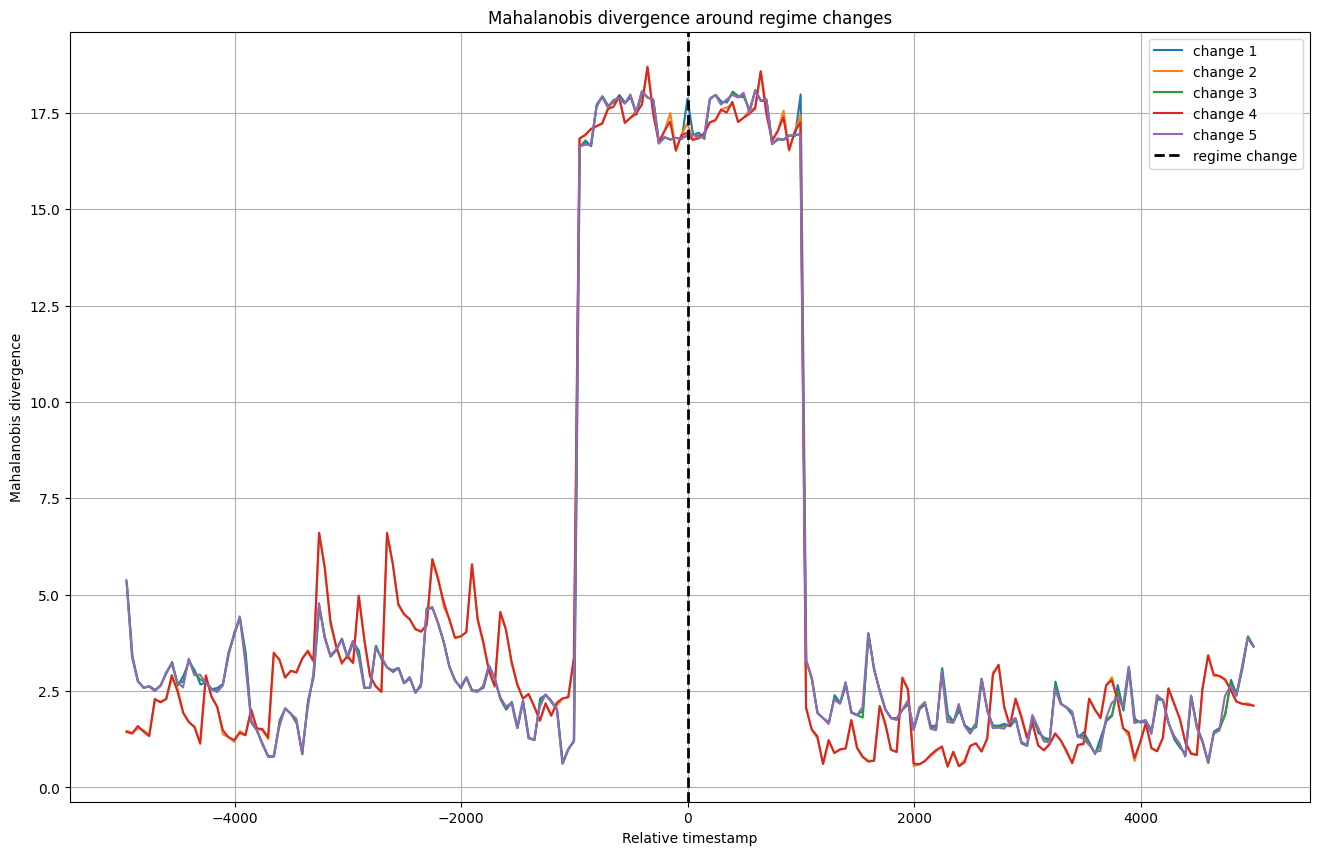

In [38]:

selected_changes = change_points[:5]

half_range = 5000

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean +-5000

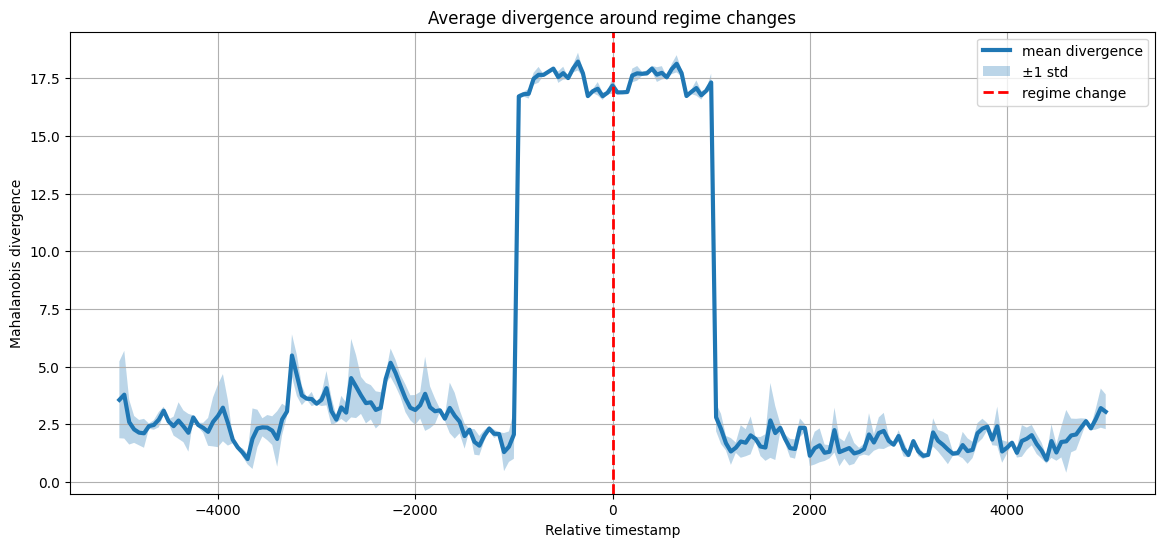

In [39]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

# same 50-stride, with window of 100

In [40]:
WINDOW = 100
STEP = 50

## features

In [41]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [42]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

### overview

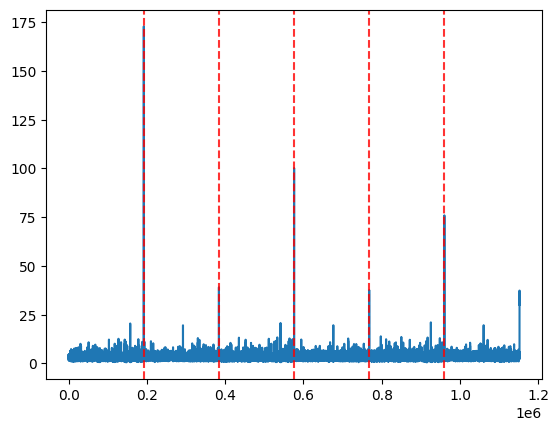

In [47]:
plt.plot(
    timestamps[timestamps < 1152006],
    scores_mahal[timestamps < 1152006],
)

for cp in change_points[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

### first 5, +- 500

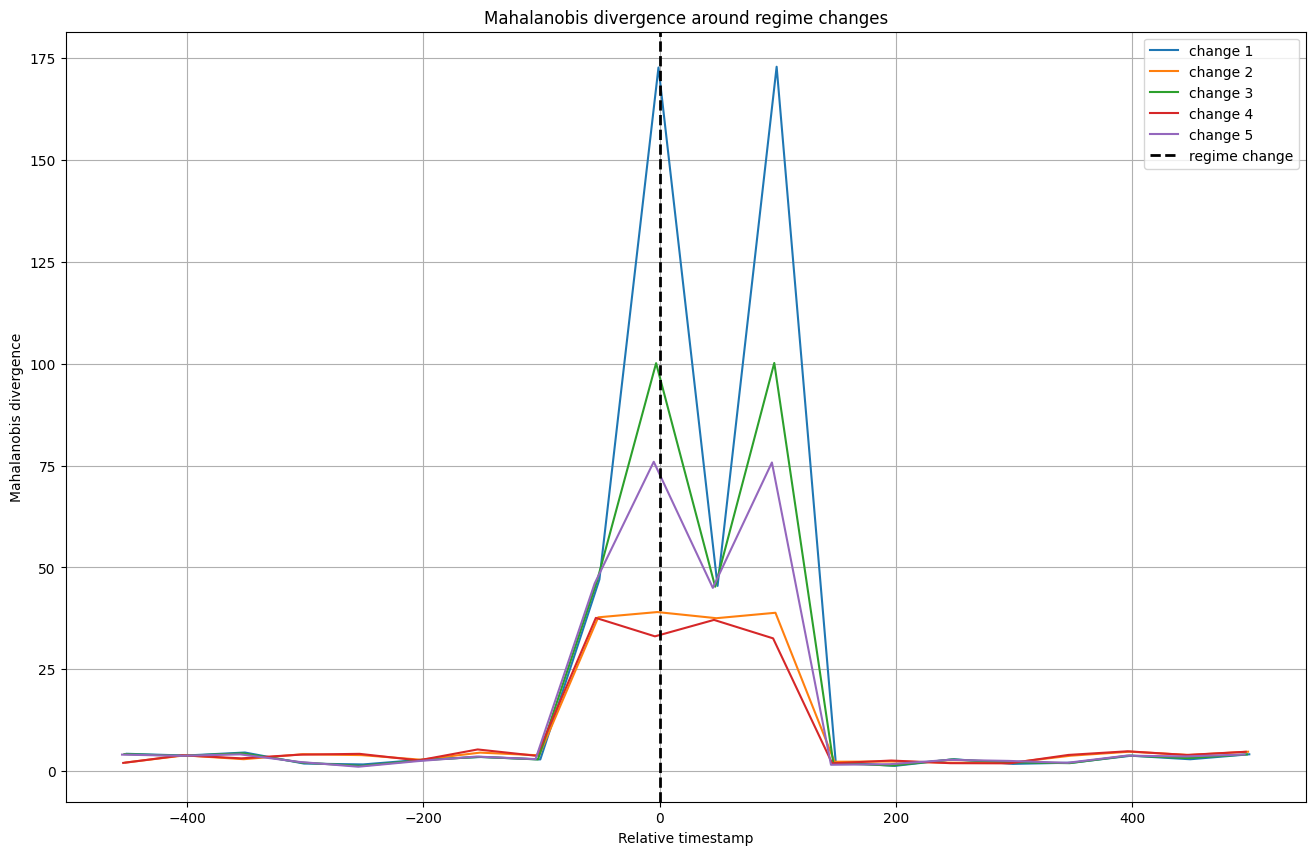

In [43]:
selected_changes = change_points[:5]

half_range = 500

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean +- 500

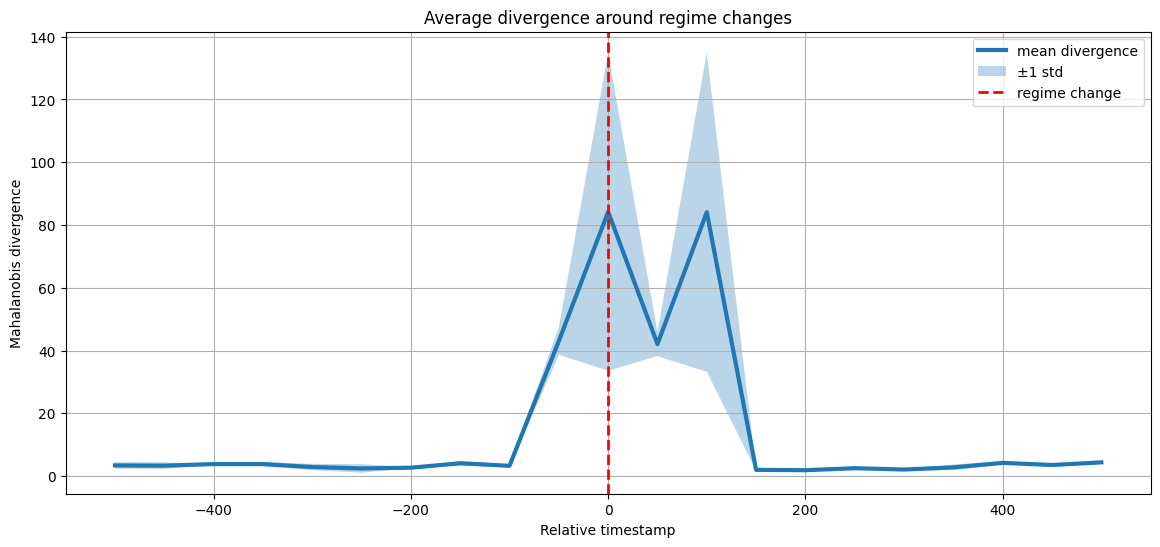

In [44]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### first +- 5000

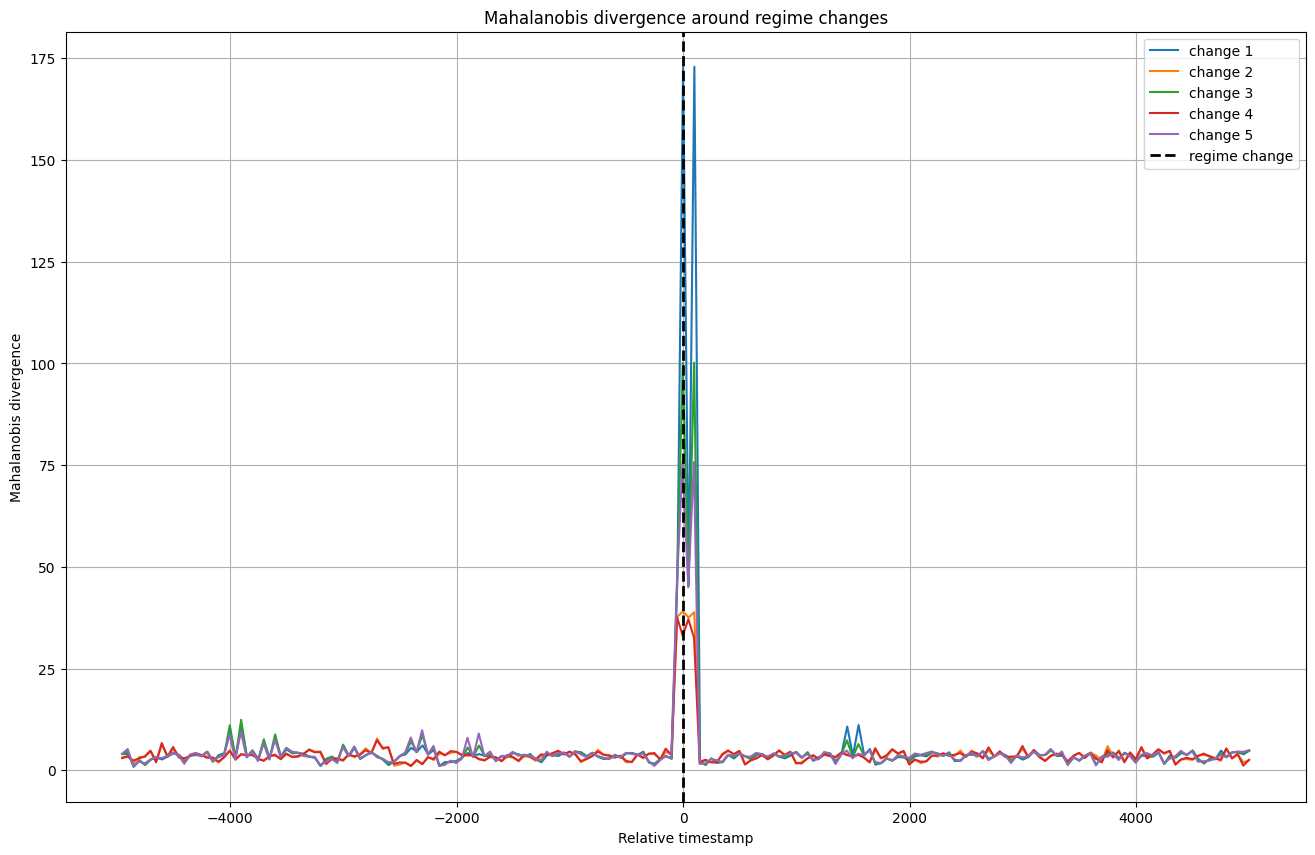

In [45]:

selected_changes = change_points[:5]

half_range = 5000

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean, +-5000

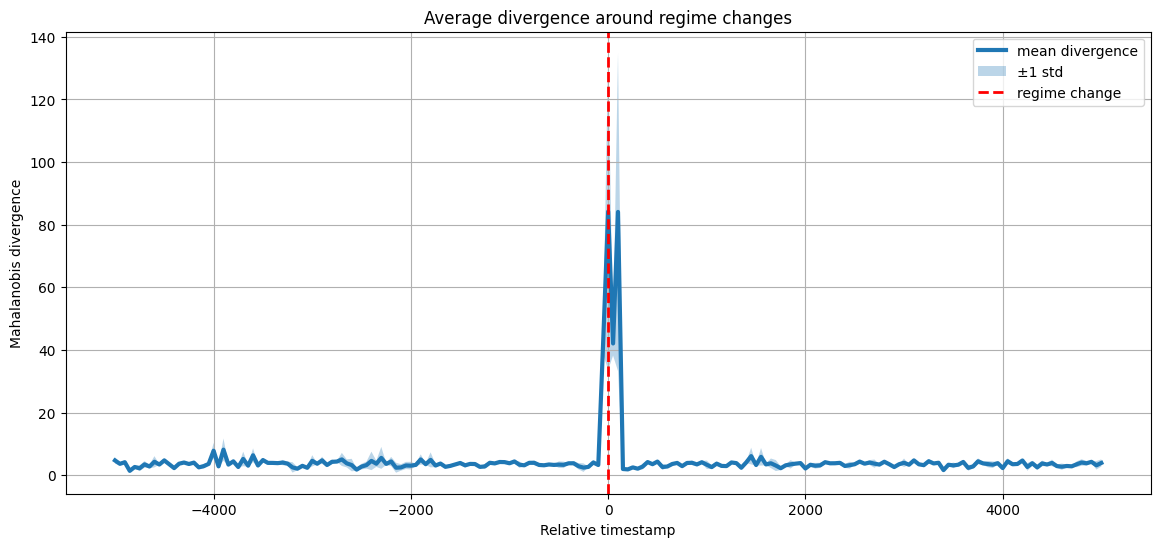

In [46]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### all mean

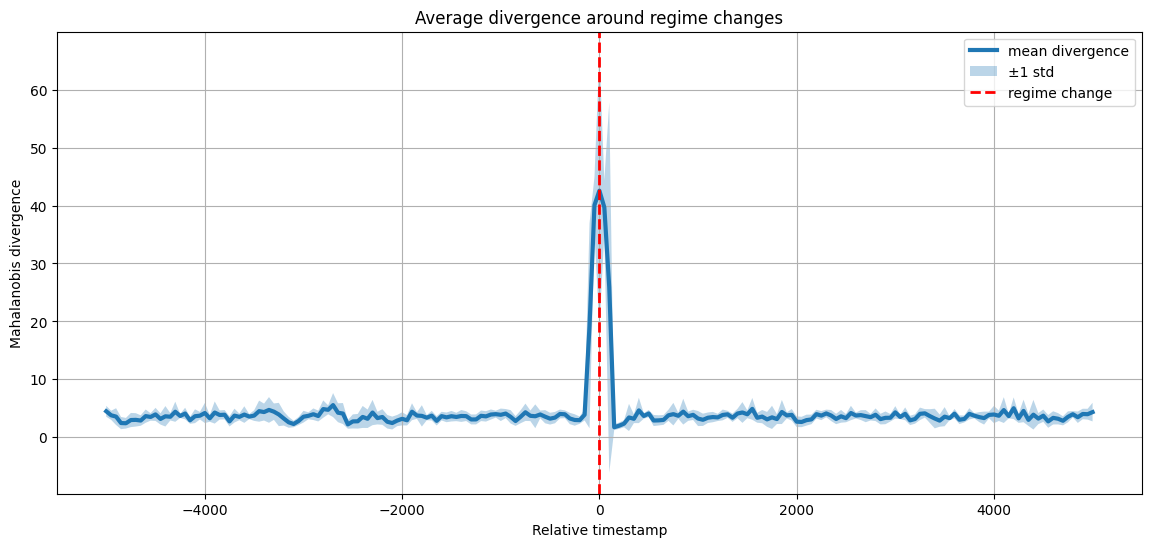

In [48]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

# on brain data

In [2]:
def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

In [3]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Extract start times
fix_cross_start = df_behav['fix_cross.started'].dropna().values
print(f"Loaded {len(fix_cross_start)} fixation cross starts")
print(f"MEG data duration: {raw.times[-1]:.2f} seconds")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [4]:
true_events = df_behav['fix_cross.started'].dropna().values

channel_name = raw.ch_names[0]
sfreq = raw.info['sfreq']
data, times = raw[channel_name, :]
data = data.flatten()

## our pipeline with stride=50, window=100 (kinda bad)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

WINDOW = 100
STEP = 50

In [16]:
true_events * int(sfreq)

array([  22891.4514,   27639.975 ,   33271.6097,   37953.4945,
         43085.2741,   48500.2874,   53515.4185,   58180.6585,
         63045.8145,   68244.2487,   72342.9729,   77124.8847,
         82923.0687,   86605.32  ,   91120.6103,   95036.0511,
        100967.553 ,  105432.8439,  109864.8545,  113813.6454,
        118762.1348,  122960.8618,  128509.1462,  133557.6263,
        137723.0031,  143287.9689,  147653.3171,  153801.4212,
        158416.6751,  162348.788 ,  166630.8514,  170896.1718,
        175294.849 ,  180859.8382,  186841.3586,  192472.933 ,
        195605.3204,  199204.2092,  202086.6388,  205835.4937,
        210017.5891,  213549.8109,  216798.8507,  220031.175 ,
        223630.0736,  227945.4395,  233027.1843,  237925.7065,
        240474.937 ,  244457.0232,  249205.5893,  253504.2545,
        257136.5009,  262851.4563,  267133.4651,  271015.5694,
        274564.4892,  277197.0332,  281229.1144,  285594.4684,
        289160.0494,  292775.6088,  297240.9105,  30125

In [41]:
events

array([  22891.4514,   27639.975 ,   33271.6097,   37953.4945,
         43085.2741,   48500.2874,   53515.4185,   58180.6585,
         63045.8145,   68244.2487,   72342.9729,   77124.8847,
         82923.0687,   86605.32  ,   91120.6103,   95036.0511,
        100967.553 ,  105432.8439,  109864.8545,  113813.6454,
        118762.1348,  122960.8618,  128509.1462,  133557.6263,
        137723.0031,  143287.9689,  147653.3171,  153801.4212,
        158416.6751,  162348.788 ,  166630.8514,  170896.1718,
        175294.849 ,  180859.8382,  186841.3586,  192472.933 ,
        195605.3204,  199204.2092,  202086.6388,  205835.4937,
        210017.5891,  213549.8109,  216798.8507,  220031.175 ,
        223630.0736,  227945.4395,  233027.1843,  237925.7065,
        240474.937 ,  244457.0232,  249205.5893,  253504.2545,
        257136.5009,  262851.4563,  267133.4651,  271015.5694,
        274564.4892,  277197.0332,  281229.1144,  285594.4684,
        289160.0494,  292775.6088,  297240.9105,  30125

In [12]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# First pass: collect all feature vectors for covariance calculation
all_features = []
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# Calculate covariance with robust handling
cov = np.cov(all_features.T)

# Check for NaN/Inf in covariance
if np.isnan(cov).any() or np.isinf(cov).any():
    print("Warning: NaN/Inf detected in covariance, replacing with zeros")
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

# Adaptive regularization strength
trace = np.trace(cov)
if trace > 0:
    reg_strength = 1e-6 * trace / cov.shape[0]
else:
    reg_strength = 1e-6

cov_reg = cov + np.eye(cov.shape[0]) * reg_strength

# Compute pseudo-inverse with singular value filtering
cov_inv = pinv(cov_reg)

# Second pass: actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_l2 = l2_distance(left_feat, right_feat)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)
    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)
scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

In [7]:
events = true_events * int(sfreq)
events[:5]

array([22891.4514, 27639.975 , 33271.6097, 37953.4945, 43085.2741])

In [22]:
events[0] - 1000

np.float64(21891.45140000028)

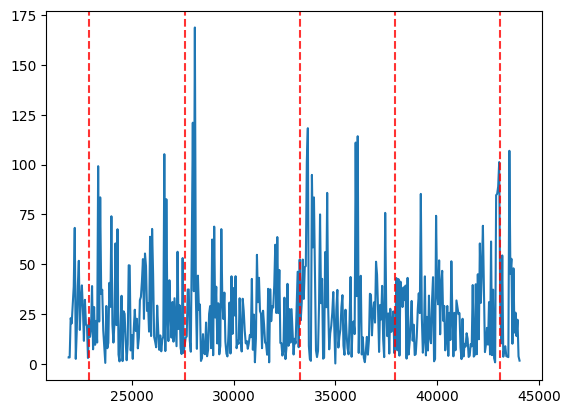

In [25]:
plt.plot(
    timestamps[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
    scores_mahal[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
)

for cp in events[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## stride = 10, window = 50

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

WINDOW = 50
STEP = 10

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# First pass: collect all feature vectors for covariance calculation
all_features = []
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# Calculate covariance with robust handling
cov = np.cov(all_features.T)

# Check for NaN/Inf in covariance
if np.isnan(cov).any() or np.isinf(cov).any():
    print("Warning: NaN/Inf detected in covariance, replacing with zeros")
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

# Adaptive regularization strength
trace = np.trace(cov)
if trace > 0:
    reg_strength = 1e-6 * trace / cov.shape[0]
else:
    reg_strength = 1e-6

cov_reg = cov + np.eye(cov.shape[0]) * reg_strength

# Compute pseudo-inverse with singular value filtering
cov_inv = pinv(cov_reg)

# Second pass: actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_l2 = l2_distance(left_feat, right_feat)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)
    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)
scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

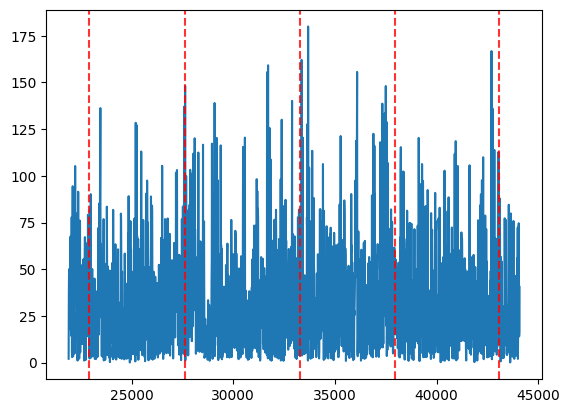

In [28]:
plt.plot(
    timestamps[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
    scores_mahal[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
)

for cp in events[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## window = 200, step = 10

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

WINDOW = 200
STEP = 10

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# First pass: collect all feature vectors for covariance calculation
all_features = []
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# Calculate covariance with robust handling
cov = np.cov(all_features.T)

# Check for NaN/Inf in covariance
if np.isnan(cov).any() or np.isinf(cov).any():
    print("Warning: NaN/Inf detected in covariance, replacing with zeros")
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

# Adaptive regularization strength
trace = np.trace(cov)
if trace > 0:
    reg_strength = 1e-6 * trace / cov.shape[0]
else:
    reg_strength = 1e-6

cov_reg = cov + np.eye(cov.shape[0]) * reg_strength

# Compute pseudo-inverse with singular value filtering
cov_inv = pinv(cov_reg)

# Second pass: actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_l2 = l2_distance(left_feat, right_feat)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)
    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)
scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

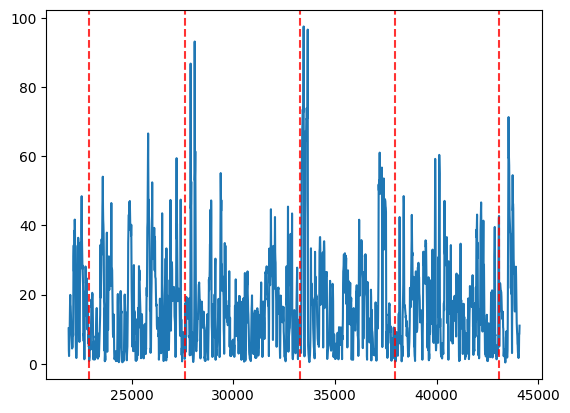

In [30]:
plt.plot(
    timestamps[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
    scores_mahal[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
)

for cp in events[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

(808, 51)


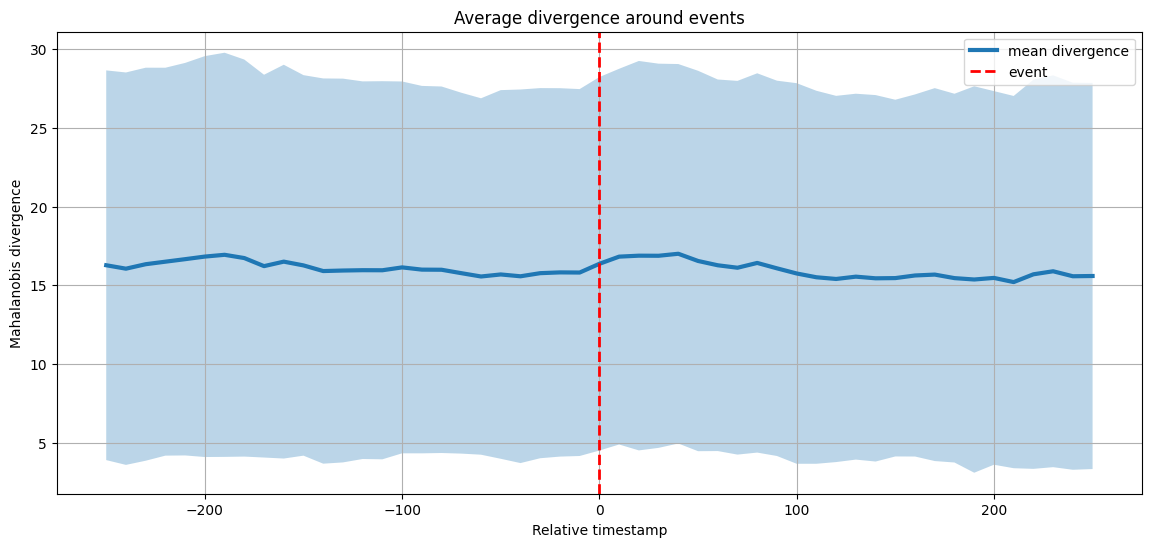

In [34]:
half_range = 250

relative_axis = np.arange(
    -half_range,
    half_range + STEP,
    STEP
)

all_curves = []

for cp in events:

    local_curve = []

    for r in relative_axis:

        target = cp + r

        # skip outside bounds
        if target < timestamps.min() or target > timestamps.max():
            local_curve.append(np.nan)
            continue

        idx = np.argmin(np.abs(timestamps - target))

        local_curve.append(scores_mahal[idx])

    all_curves.append(local_curve)

all_curves = np.array(all_curves)

print(all_curves.shape)

# ============================================================
# AGGREGATE
# ============================================================

mean_curve = np.nanmean(all_curves, axis=0)
std_curve = np.nanstd(all_curves, axis=0)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='event'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around events')

plt.legend()
plt.grid(True)

plt.show()

# Bayesian search

In [43]:
# Bayesian Optimization Pipeline for Regime Change Divergence Detection
# Simplified version with STEP and WINDOW only

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

# ============================================================
# CONFIG
# ============================================================

EVENT_MATCH_THRESHOLD = 50  # distance to count true positive
N_CALLS = 30  # Number of optimization iterations
RANDOM_STATE = 42

OUTPUT_DIR = 'bayes_regime_search'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# DISTANCE METRICS
# ============================================================

def l2_distance(left, right):
    """Euclidean distance between feature vectors"""
    return np.linalg.norm(left - right)

def mahalanobis_distance(left, right, cov_inv):
    """Mahalanobis distance with precomputed inverse covariance"""
    return mahalanobis(left, right, cov_inv)

def relative_change(left, right):
    """Mean relative change between features"""
    eps = 1e-8
    rel = np.abs(right - left) / (np.abs(left) + eps)
    return np.mean(rel)

# ============================================================
# PEAK EVALUATION (Local Minima Detection)
# ============================================================

def evaluate_minima(minima, events):
    """
    Evaluate detected local minima against ground truth events.
    True positive: minima within 50 timestamps of an event
    False positive: minima 51+ timestamps away from any event

    Args:
        minima: Detected local minima timestamps
        events: Ground truth event timestamps

    Returns:
        Dictionary with evaluation metrics
    """
    tp = 0
    fp = 0
    matched_minima = set()

    # True Positives: minima close to events
    for ev in events:
        if len(minima) == 0:
            continue

        distances = np.abs(minima - ev)
        idx = np.argmin(distances)

        if distances[idx] <= EVENT_MATCH_THRESHOLD:
            tp += 1
            matched_minima.add(idx)

    # False Positives: minima far from any event
    for i, peak in enumerate(minima):
        if i not in matched_minima:
            distances = np.abs(events - peak)
            if len(distances) == 0 or np.min(distances) > EVENT_MATCH_THRESHOLD:
                fp += 1

    # Calculate metrics
    fn = len(events) - tp  # False negatives: events not detected

    # Accuracy: (TP) / (TP + FP + FN)
    total_detections = tp + fp + fn
    accuracy = tp / (total_detections + 1e-8)

    # Precision: TP / (TP + FP)
    precision = tp / (tp + fp + 1e-8)

    # Recall: TP / (TP + FN)
    recall = tp / (tp + fn + 1e-8)

    # F1 Score
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    # Custom score: Accuracy with FP penalty
    score = accuracy - 0.1 * (fp / (tp + fn + 1e-8))

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'score': float(score)
    }

# ============================================================
# SEARCH SPACE (Only STEP and WINDOW)
# ============================================================

space = [
    Integer(20, 500, name='WINDOW'),  # Window size
    Integer(5, 100, name='STEP')       # Step size
]

# ============================================================
# OPTIMIZATION OBJECTIVE
# ============================================================

trial_counter = 0
results = []
evaluated_points = []  # Store (WINDOW, STEP, score) for heatmap

@use_named_args(space)
def objective(WINDOW, STEP):
    """
    Objective function for Bayesian optimization.
    Evaluates a single trial with given WINDOW and STEP parameters.
    """
    global trial_counter

    trial_counter += 1

    # print(f'\n{"="*60}')
    print(f'Trial {trial_counter}: WINDOW={WINDOW}, STEP={STEP}')
    # print(f'{"="*60}')

    # ========================================================
    # FIRST PASS: Collect features for covariance
    # ========================================================

    all_features = []

    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]

        left_feat, feature_names = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        all_features.append(left_feat)
        all_features.append(right_feat)

    if len(all_features) == 0:
        print(f"Warning: No features extracted with WINDOW={WINDOW}, STEP={STEP}")
        return -1.0  # Return low score for invalid parameters

    all_features = np.array(all_features)

    # Calculate covariance with robust handling
    cov = np.cov(all_features.T)

    # Handle NaN/Inf
    if np.isnan(cov).any() or np.isinf(cov).any():
        cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

    # Adaptive regularization
    trace = np.trace(cov)
    if trace > 0:
        reg_strength = 1e-6 * trace / cov.shape[0]
    else:
        reg_strength = 1e-6

    cov_reg = cov + np.eye(cov.shape[0]) * reg_strength
    cov_inv = pinv(cov_reg)

    # ========================================================
    # SECOND PASS: Calculate divergence scores
    # ========================================================

    timestamps = []
    scores_l2 = []
    scores_mahal = []
    scores_rel = []

    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]

        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        s_l2 = l2_distance(left_feat, right_feat)
        s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
        s_rel = relative_change(left_feat, right_feat)

        timestamps.append(t)
        scores_l2.append(s_l2)
        scores_mahal.append(s_mahal)
        scores_rel.append(s_rel)

    scores_l2 = np.array(scores_l2)
    scores_rel = np.array(scores_rel)

    timestamps = np.array(timestamps)
    scores_mahal = np.array(scores_mahal)

    # ========================================================
    # FIND LOCAL MINIMA (where divergence drops)
    # ========================================================

    # Find local minima in Mahalanobis divergence
    minima_idx, properties = find_peaks(-scores_mahal)

    # Filter minima based on prominence
    if len(minima_idx) > 0 and 'peak_heights' in properties:
        # Keep minima with sufficient prominence
        prominence_threshold = np.std(scores_mahal) * 0.5
        minima_idx = minima_idx[properties['peak_heights'] > prominence_threshold]

    minima_timestamps = timestamps[minima_idx]

    # ========================================================
    # EVALUATE DETECTED MINIMA
    # ========================================================

    metrics = evaluate_minima(minima_timestamps, events)

    print(f"Results:")
    print(f"  Detected minima: {len(minima_timestamps)}")
    print(f"  TP: {metrics['tp']}, FP: {metrics['fp']}, FN: {metrics['fn']}")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall: {metrics['recall']:.3f}")
    print(f"  F1: {metrics['f1']:.3f}")
    print(f"  Score: {metrics['score']:.3f}")

    # Store results
    result = {
        'trial': trial_counter,
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        **metrics
    }
    results.append(result)
    evaluated_points.append({
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        'score': metrics['score']
    })

    # Save results to JSON
    with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    # ========================================================
    # CREATE PLOT FOR THIS TRIAL
    # ========================================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Plot 1: Mahalanobis divergence with minima
    ax1 = axes[0, 0]
    ax1.plot(timestamps, scores_mahal, linewidth=1.5, alpha=0.7, label='Mahalanobis divergence')
    ax1.scatter(minima_timestamps, scores_mahal[minima_idx],
               c='red', s=50, zorder=5, label=f'Detected minima (n={len(minima_timestamps)})')

    for ev in events:
        ax1.axvline(ev, color='green', linestyle='--', alpha=0.5, linewidth=1)

    ax1.set_xlabel('Timestamp')
    ax1.set_ylabel('Mahalanobis divergence')
    ax1.set_title(f'Trial {trial_counter}: WINDOW={WINDOW}, STEP={STEP}\nScore={metrics["score"]:.3f}, Acc={metrics["accuracy"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: L2 distance
    ax2 = axes[0, 1]
    ax2.plot(timestamps, scores_l2, linewidth=1.5, alpha=0.7, color='orange', label='L2 distance')
    ax2.set_xlabel('Timestamp')
    ax2.set_ylabel('L2 Distance')
    ax2.set_title('L2 Distance')
    ax2.grid(True, alpha=0.3)

    # Plot 3: Relative change
    ax3 = axes[1, 0]
    ax3.plot(timestamps, scores_rel, linewidth=1.5, alpha=0.7, color='green', label='Relative change')
    ax3.set_xlabel('Timestamp')
    ax3.set_ylabel('Relative Change')
    ax3.set_title('Relative Change')
    ax3.grid(True, alpha=0.3)

    # Plot 4: All divergences together
    ax4 = axes[1, 1]
    # Normalize for comparison
    ax4.plot(timestamps, scores_mahal / (scores_mahal.max() + 1e-8),
            linewidth=1.5, label='Mahalanobis (norm)', alpha=0.7)
    ax4.plot(timestamps, scores_l2 / (scores_l2.max() + 1e-8),
            linewidth=1.5, label='L2 (norm)', alpha=0.7)
    ax4.plot(timestamps, scores_rel / (scores_rel.max() + 1e-8),
            linewidth=1.5, label='Relative (norm)', alpha=0.7)
    ax4.set_xlabel('Timestamp')
    ax4.set_ylabel('Normalized Score')
    ax4.set_title('Normalized Divergence Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f'trial_{trial_counter:03d}.png'),
                bbox_inches='tight', dpi=150)
    plt.close(fig)

    # Return negative score for minimization
    return -metrics['score']

# ============================================================
# HEATMAP VISUALIZATION
# ============================================================

def create_heatmap_with_points():
    """Create a heatmap of the search space with evaluated points"""

    if len(evaluated_points) == 0:
        print("No points to plot")
        return

    # Create grid for heatmap
    window_range = np.linspace(20, 500, 50)
    step_range = np.linspace(5, 100, 50)
    W_grid, S_grid = np.meshgrid(window_range, step_range)

    # Create score matrix (using inverse distance weighting for interpolation)
    from scipy.interpolate import griddata

    points = np.array([[p['WINDOW'], p['STEP']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    # Interpolate scores to grid
    grid_scores = griddata(points, scores, (W_grid, S_grid), method='cubic', fill_value=-1)

    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 10))

    # Plot heatmap
    im = ax.imshow(grid_scores, extent=[20, 500, 5, 100],
                   origin='lower', aspect='auto', cmap='viridis',
                   interpolation='bilinear', alpha=0.8)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Accuracy Score', fontsize=12)

    # Plot evaluated points
    scatter = ax.scatter(points[:, 0], points[:, 1], c=scores,
                        s=100, cmap='viridis', edgecolors='black',
                        linewidths=1.5, zorder=5)

    # Highlight best point
    best_idx = np.argmax(scores)
    ax.scatter(points[best_idx, 0], points[best_idx, 1],
              c='red', s=300, marker='*', edgecolors='white',
              linewidths=2, zorder=6,
              label=f'Best: W={int(points[best_idx, 0])}, S={int(points[best_idx, 1])}\nScore={scores[best_idx]:.3f}')

    # Add labels for each point
    for i, (w, s) in enumerate(points):
        ax.annotate(f'{scores[i]:.2f}', (w, s),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.7)

    ax.set_xlabel('Window Size', fontsize=12)
    ax.set_ylabel('Step Size', fontsize=12)
    ax.set_title('Bayesian Search Heatmap: Window vs Step\nPoints show evaluated trials', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2, linestyle='--')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'heatmap_with_points.png'),
                bbox_inches='tight', dpi=150)
    plt.close()

    # Create additional 3D surface plot
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Create surface
    surf = ax.plot_surface(W_grid, S_grid, grid_scores, cmap='viridis',
                          alpha=0.6, edgecolor='none')

    # Add scatter points
    ax.scatter(points[:, 0], points[:, 1], scores,
              c='red', s=100, depthshade=True, alpha=0.8)

    # Highlight best
    ax.scatter(points[best_idx, 0], points[best_idx, 1], scores[best_idx],
              c='yellow', s=200, marker='*', depthshade=True)

    ax.set_xlabel('Window Size', fontsize=11)
    ax.set_ylabel('Step Size', fontsize=11)
    ax.set_zlabel('Accuracy Score', fontsize=11)
    ax.set_title('3D Surface Plot of Search Space', fontsize=14)

    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    cbar.set_label('Score')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'heatmap_3d.png'),
                bbox_inches='tight', dpi=150)
    plt.close()

def plot_optimization_summary():
    """Create a summary of the optimization process"""

    if len(results) == 0:
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Score improvement over trials
    ax1 = axes[0, 0]
    trials = [r['trial'] for r in results]
    scores = [r['score'] for r in results]
    best_scores = np.maximum.accumulate(scores)

    ax1.plot(trials, scores, 'o-', label='Trial Score', alpha=0.5, markersize=6)
    ax1.plot(trials, best_scores, 'r-', linewidth=2, label='Best So Far')
    ax1.set_xlabel('Trial Number')
    ax1.set_ylabel('Score (Accuracy)')
    ax1.set_title('Optimization Progress')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Parameters over trials
    ax2 = axes[0, 1]
    windows = [r['WINDOW'] for r in results]
    steps = [r['STEP'] for r in results]

    ax2.scatter(trials, windows, label='Window Size', alpha=0.6, s=50)
    ax2.scatter(trials, steps, label='Step Size', alpha=0.6, s=50)
    ax2.set_xlabel('Trial Number')
    ax2.set_ylabel('Parameter Value')
    ax2.set_title('Parameter Exploration')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Accuracy metrics over time
    ax3 = axes[1, 0]
    accuracies = [r['accuracy'] for r in results]
    precisions = [r['precision'] for r in results]
    recalls = [r['recall'] for r in results]

    ax3.plot(trials, accuracies, 'o-', label='Accuracy', alpha=0.6)
    ax3.plot(trials, precisions, 's-', label='Precision', alpha=0.6)
    ax3.plot(trials, recalls, '^-', label='Recall', alpha=0.6)
    ax3.set_xlabel('Trial Number')
    ax3.set_ylabel('Score')
    ax3.set_title('Performance Metrics Evolution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: TP/FP counts
    ax4 = axes[1, 1]
    tp_counts = [r['tp'] for r in results]
    fp_counts = [r['fp'] for r in results]
    fn_counts = [r['fn'] for r in results]

    ax4.plot(trials, tp_counts, 'g-', label='True Positives', linewidth=2)
    ax4.plot(trials, fp_counts, 'r-', label='False Positives', linewidth=2)
    ax4.plot(trials, fn_counts, 'orange', label='False Negatives', linewidth=2)
    ax4.set_xlabel('Trial Number')
    ax4.set_ylabel('Count')
    ax4.set_title('Detection Statistics')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Bayesian Optimization Summary', fontsize=16, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'optimization_summary.png'),
                bbox_inches='tight', dpi=150)
    plt.close()

print("Starting Bayesian Optimization...")
print(f"Search space: WINDOW [20-500], STEP [5-100]")
print(f"Total evaluations: {N_CALLS}")
print("="*60)

optimization_result = gp_minimize(
    objective,
    space,
    n_calls=N_CALLS,
    n_initial_points=10,  # Initial random exploration
    random_state=RANDOM_STATE,
    verbose=True
)

# ============================================================
# POST-PROCESSING VISUALIZATIONS
# ============================================================

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)

# Find best trial
best_idx = np.argmax([r['score'] for r in results])
best_trial = results[best_idx]

print(f"\nBest Parameters Found:")
print(f"  WINDOW: {best_trial['WINDOW']}")
print(f"  STEP: {best_trial['STEP']}")
print(f"  Score: {best_trial['score']:.4f}")
print(f"  Accuracy: {best_trial['accuracy']:.4f}")
print(f"  Precision: {best_trial['precision']:.4f}")
print(f"  Recall: {best_trial['recall']:.4f}")
print(f"  F1: {best_trial['f1']:.4f}")

# Save best parameters
with open(os.path.join(OUTPUT_DIR, 'best_parameters.json'), 'w') as f:
    json.dump(best_trial, f, indent=2)

# Create visualizations
print("\nGenerating visualizations...")
create_heatmap_with_points()
plot_optimization_summary()

# Plot convergence
fig, ax = plt.subplots(figsize=(12, 6))
plot_convergence(optimization_result, ax=ax)
ax.set_title('Bayesian Optimization Convergence', fontsize=14)
ax.set_xlabel('Number of Calls', fontsize=12)
ax.set_ylabel('Best Score Found', fontsize=12)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT_DIR, 'convergence.png'), bbox_inches='tight', dpi=150)
plt.close()

print(f"\nAll results saved to '{OUTPUT_DIR}' directory")
print("Files generated:")
print("  - trial_*.png: Individual trial visualizations")
print("  - heatmap_with_points.png: 2D heatmap with evaluated points")
print("  - heatmap_3d.png: 3D surface plot")
print("  - optimization_summary.png: Summary plots")
print("  - convergence.png: Convergence plot")
print("  - results.json: All trial results")
print("  - best_parameters.json: Best parameters found")

Starting Bayesian Optimization...
Search space: WINDOW [20-500], STEP [5-100]
Total evaluations: 30
Iteration No: 1 started. Evaluating function at random point.

Trial 1: WINDOW=402, STEP=22
Results:
  Detected minima: 23215
  TP: 607, FP: 22460, FN: 201
  Accuracy: 0.026
  Precision: 0.026
  Recall: 0.751
  F1: 0.051
  Score: -2.754
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 46.4257
Function value obtained: 2.7536
Current minimum: 2.7536
Iteration No: 2 started. Evaluating function at random point.

Trial 2: WINDOW=394, STEP=62
Results:
  Detected minima: 10480
  TP: 341, FP: 10139, FN: 467
  Accuracy: 0.031
  Precision: 0.033
  Recall: 0.422
  F1: 0.060
  Score: -1.224
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 15.8918
Function value obtained: 1.2237
Current minimum: 1.2237
Iteration No: 3 started. Evaluating function at random point.

Trial 3: WINDOW=234, STEP=14
Results:
  Detected minima: 39497
  TP: 756, FP: 38207, FN: 52
  Accur

# tp objective

In [8]:
# Bayesian Optimization Pipeline for Regime Change Divergence Detection
# Simplified: Only STEP and WINDOW, TP score only

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args

# ============================================================
# CONFIG
# ============================================================

EVENT_MATCH_THRESHOLD = 50
N_CALLS = 30
RANDOM_STATE = 42
OUTPUT_DIR = 'bayes_regime_search_tp_run2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# DISTANCE METRICS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)

def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)

def relative_change(left, right):
    eps = 1e-8
    rel = np.abs(right - left) / (np.abs(left) + eps)
    return np.mean(rel)

# ============================================================
# EVALUATION
# ============================================================

def evaluate_minima(minima, events):
    tp = 0
    fp = 0
    matched_minima = set()

    for ev in events:
        if len(minima) == 0:
            continue
        distances = np.abs(minima - ev)
        idx = np.argmin(distances)
        if distances[idx] <= EVENT_MATCH_THRESHOLD:
            tp += 1
            matched_minima.add(idx)

    for i, peak in enumerate(minima):
        if i not in matched_minima:
            distances = np.abs(events - peak)
            if len(distances) == 0 or np.min(distances) > EVENT_MATCH_THRESHOLD:
                fp += 1

    fn = len(events) - tp
    accuracy = tp / (tp + fp + fn + 1e-8)

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'accuracy': float(accuracy),
        'score': float(tp - fp * 1e-6)  # TP only
    }

# ============================================================
# SEARCH SPACE
# ============================================================

space = [
    Integer(20, 200, name='WINDOW'),
    Integer(10, 40, name='STEP')
]

# ============================================================
# GLOBALS
# ============================================================

trial_counter = 0
results = []
evaluated_points = []

# ============================================================
# HEATMAP UPDATE (only when enough points)
# ============================================================

def update_heatmap():
    if len(evaluated_points) < 4:  # Need at least 4 points for cubic interpolation
        return

    from scipy.interpolate import griddata

    window_range = np.linspace(20, 500, 50)
    step_range = np.linspace(5, 100, 50)
    W_grid, S_grid = np.meshgrid(window_range, step_range)

    points = np.array([[p['WINDOW'], p['STEP']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    # Use linear interpolation instead of cubic to avoid issues
    grid_scores = griddata(points, scores, (W_grid, S_grid), method='linear', fill_value=-1)

    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(grid_scores, extent=[20, 500, 5, 100],
                   origin='lower', aspect='auto', cmap='viridis', alpha=0.8)

    plt.colorbar(im, ax=ax, label='TP Score')

    # Plot evaluated points
    ax.scatter(points[:, 0], points[:, 1], c='red', s=80, edgecolors='black', linewidths=1.5, zorder=5)

    # Label points with trial numbers
    for i, (w, s) in enumerate(points):
        ax.annotate(f'{evaluated_points[i]["trial"]}', (w, s),
                   xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Highlight best
    best_idx = np.argmax(scores)
    ax.scatter(points[best_idx, 0], points[best_idx, 1],
              c='red', s=300, marker='*', edgecolors='white', linewidths=2, zorder=6)

    ax.set_xlabel('Window Size')
    ax.set_ylabel('Step Size')
    ax.set_title(f'Search Heatmap ({len(evaluated_points)} trials)')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'current_heatmap.png'), bbox_inches='tight', dpi=150)
    plt.close(fig)

# ============================================================
# OBJECTIVE FUNCTION
# ============================================================

@use_named_args(space)
def objective(WINDOW, STEP):
    global trial_counter

    trial_counter += 1
    print(f'Trial {trial_counter}: W={WINDOW}, S={STEP}')

    # First pass: collect features
    all_features = []
    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]
        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)
        all_features.append(left_feat)
        all_features.append(right_feat)

    if len(all_features) == 0:
        return -1.0

    all_features = np.array(all_features)

    # Covariance
    cov = np.cov(all_features.T)
    if np.isnan(cov).any() or np.isinf(cov).any():
        cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

    trace = np.trace(cov)
    reg_strength = 1e-6 * trace / cov.shape[0] if trace > 0 else 1e-6
    cov_reg = cov + np.eye(cov.shape[0]) * reg_strength
    cov_inv = pinv(cov_reg)

    # Second pass: calculate scores
    timestamps = []
    scores_mahal = []

    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]
        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)
        s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
        timestamps.append(t)
        scores_mahal.append(s_mahal)

    timestamps = np.array(timestamps)
    scores_mahal = np.array(scores_mahal)

    # Find local minima
    # scores_mahal_normalized = (scores_mahal - scores_mahal.min()) / (scores_mahal.max() - scores_mahal.min())

    minima_idx, _ = find_peaks(-scores_mahal, wlen=4)#, prominence=0.1, wlen=4)
    # keep peaks that descend at least 0.3 in normalized units
    minima_timestamps = timestamps[minima_idx]

    # Evaluate
    metrics = evaluate_minima(minima_timestamps, events)
    print(f'  TP={metrics["tp"]}, FP={metrics["fp"]}, FN={metrics["fn"]}')

    # Store
    result = {
        'trial': trial_counter,
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        **metrics
    }
    results.append(result)
    evaluated_points.append({
        'trial': trial_counter,
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        'score': metrics['score']
    })

    with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    update_heatmap()

    return -metrics['score']

# ============================================================
# FINAL HEATMAP
# ============================================================

def final_heatmap():
    if len(evaluated_points) < 4:
        print("Not enough points for heatmap")
        return

    from scipy.interpolate import griddata

    window_range = np.linspace(20, 500, 100)
    step_range = np.linspace(5, 100, 100)
    W_grid, S_grid = np.meshgrid(window_range, step_range)

    points = np.array([[p['WINDOW'], p['STEP']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    grid_scores = griddata(points, scores, (W_grid, S_grid), method='linear', fill_value=-1)

    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(grid_scores, extent=[20, 500, 5, 100],
                   origin='lower', aspect='auto', cmap='plasma', alpha=0.85)

    plt.colorbar(im, ax=ax, label='True Positives (TP)')

    best_idx = np.argmax(scores)
    for i, (w, s) in enumerate(points):
        color = 'red' if i == best_idx else 'white'
        size = 200 if i == best_idx else 80
        marker = '*' if i == best_idx else 'o'
        ax.scatter(w, s, c=color, s=size, marker=marker, edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(f'{evaluated_points[i]["trial"]}', (w, s),
                   xytext=(8, 8), textcoords='offset points', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    ax.set_xlabel('Window Size', fontsize=12)
    ax.set_ylabel('Step Size', fontsize=12)
    ax.set_title(f'Final Heatmap: Best TP={scores[best_idx]:.0f} at W={int(points[best_idx,0])}, S={int(points[best_idx,1])}', fontsize=14)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'final_heatmap.png'), bbox_inches='tight', dpi=150)
    plt.close()

# ============================================================
# RUN OPTIMIZATION
# ============================================================

print(f"Starting Bayesian Optimization: {N_CALLS} trials")
print(f"Search: WINDOW[20-500], STEP[5-100]")
print("="*50)

optimization_result = gp_minimize(
    objective,
    space,
    n_calls=N_CALLS,
    n_initial_points=10,
    random_state=RANDOM_STATE,
    verbose=False
)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "="*50)
print("OPTIMIZATION COMPLETE")
print("="*50)

# Find best
best_idx = np.argmax([r['score'] for r in results])
best = results[best_idx]

print(f"\nBest parameters:")
print(f"  WINDOW: {best['WINDOW']}")
print(f"  STEP: {best['STEP']}")
print(f"  TP: {best['score']:.0f}")
print(f"  FP: {best['fp']}")
print(f"  FN: {best['fn']}")
print(f"  Accuracy: {best['accuracy']:.3f}")

# Save best
with open(os.path.join(OUTPUT_DIR, 'best_parameters.json'), 'w') as f:
    json.dump(best, f, indent=2)

# Generate final heatmap
final_heatmap()

Starting Bayesian Optimization: 30 trials
Search: WINDOW[20-500], STEP[5-100]
Trial 1: W=163, S=16
  TP=769, FP=37889, FN=39
Trial 2: W=160, S=28
  TP=650, FP=23281, FN=158
Trial 3: W=100, S=13
  TP=795, FP=51692, FN=13
Trial 4: W=103, S=20
  TP=756, FP=34622, FN=52
Trial 5: W=46, S=30
  TP=717, FP=27369, FN=91
Trial 6: W=30, S=32
  TP=685, FP=24544, FN=123
Trial 7: W=189, S=10
  TP=793, FP=55027, FN=15
Trial 8: W=199, S=29
  TP=595, FP=21139, FN=213
Trial 9: W=130, S=10
  TP=800, FP=61010, FN=8
Trial 10: W=24, S=26
  TP=748, FP=30367, FN=60
Trial 11: W=20, S=10
  TP=805, FP=90177, FN=3
Trial 12: W=20, S=14
  TP=805, FP=57458, FN=3
Trial 13: W=27, S=10
  TP=805, FP=81489, FN=3
Trial 14: W=20, S=12
  TP=805, FP=69588, FN=3
Trial 15: W=20, S=16
  TP=805, FP=49885, FN=3
Trial 16: W=72, S=10
  TP=804, FP=70980, FN=4
Trial 17: W=20, S=15
  TP=803, FP=53510, FN=5
Trial 18: W=31, S=10
  TP=805, FP=80999, FN=3
Trial 19: W=20, S=17
  TP=798, FP=46641, FN=10
Trial 20: W=20, S=11
  TP=805, FP=792

# how do we find peaks? from persistency to hand-crafted TODO

teager energy

probably do bayesian search with find_peaks parameters too

# best

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

WINDOW = 10
STEP = 16

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# First pass: collect all feature vectors for covariance calculation
all_features = []
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# Calculate covariance with robust handling
cov = np.cov(all_features.T)

# Check for NaN/Inf in covariance
if np.isnan(cov).any() or np.isinf(cov).any():
    print("Warning: NaN/Inf detected in covariance, replacing with zeros")
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

# Adaptive regularization strength
trace = np.trace(cov)
if trace > 0:
    reg_strength = 1e-6 * trace / cov.shape[0]
else:
    reg_strength = 1e-6

cov_reg = cov + np.eye(cov.shape[0]) * reg_strength

# Compute pseudo-inverse with singular value filtering
cov_inv = pinv(cov_reg)

# Second pass: actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_l2 = l2_distance(left_feat, right_feat)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)
    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)
scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

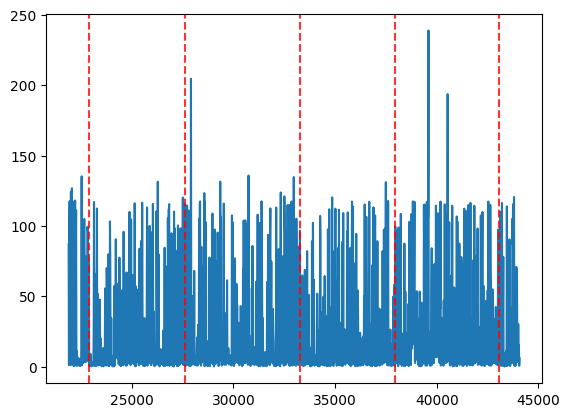

In [10]:
plt.plot(
    timestamps[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
    scores_mahal[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
)

for cp in events[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# just try whatever

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

WINDOW = 1000
STEP = 1

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# First pass: collect all feature vectors for covariance calculation
all_features = []
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# Calculate covariance with robust handling
cov = np.cov(all_features.T)

# Check for NaN/Inf in covariance
if np.isnan(cov).any() or np.isinf(cov).any():
    print("Warning: NaN/Inf detected in covariance, replacing with zeros")
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

# Adaptive regularization strength
trace = np.trace(cov)
if trace > 0:
    reg_strength = 1e-6 * trace / cov.shape[0]
else:
    reg_strength = 1e-6

cov_reg = cov + np.eye(cov.shape[0]) * reg_strength

# Compute pseudo-inverse with singular value filtering
cov_inv = pinv(cov_reg)

# Second pass: actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_l2 = l2_distance(left_feat, right_feat)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)
    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)
scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

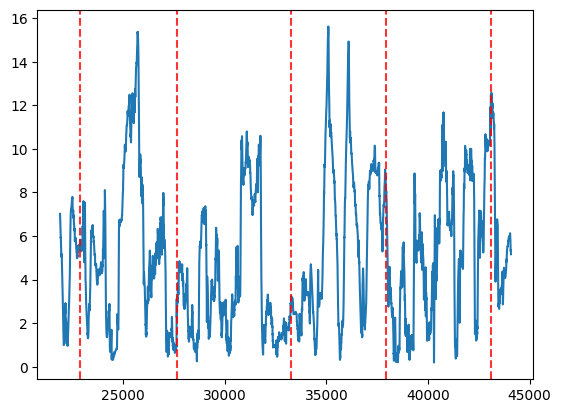

In [12]:
plt.plot(
    timestamps[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
    scores_mahal[(timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)],
)

for cp in events[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## good plot

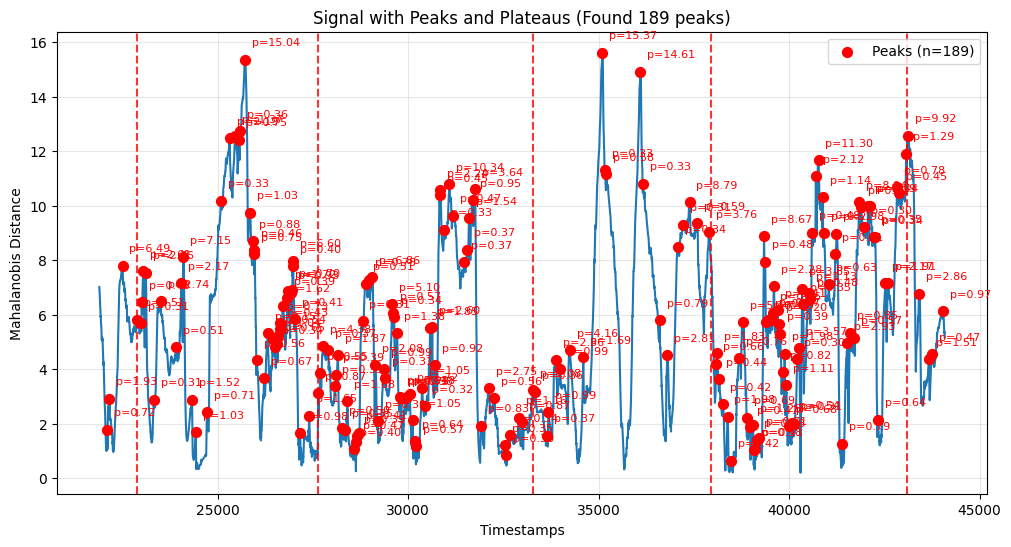


PEAK DETECTION RESULTS
Total peaks found: 189

Index  Timestamp    Value      Prominence   Width     
------------------------------------------------------------
0      22099.00     1.773      0.722        7.6       
1      22159.00     2.919      1.928        90.2      
2      22501.00     7.796      6.486        762.4     
3      22878.00     5.813      0.511        14.6      
4      22987.00     5.694      0.307        8.9       
5      23006.00     6.446      0.431        6.1       
6      23042.00     7.600      2.615        44.9      
7      23111.00     7.544      2.750        36.6      
8      23326.00     2.878      0.310        17.3      
9      23501.00     6.505      2.739        198.5     
10     23907.00     4.794      0.506        42.1      
11     24044.00     7.158      2.173        40.6      
12     24100.00     8.109      7.153        153.0     
13     24325.00     2.881      1.516        69.8      
14     24424.00     1.694      1.029        25.6      
15     2471

In [13]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# Filter data within the time window
mask = (timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)
filtered_timestamps = timestamps[mask]
filtered_scores = scores_mahal[mask]

# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.plot(filtered_timestamps, filtered_scores)

# Add vertical lines for events
for cp in events[:5]:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.8)

# Find peaks with prominence
peaks, properties = find_peaks(filtered_scores,
                               prominence=0.3,  # Adjust as needed
                               width=1,         # Minimum width in samples
                               rel_height=0.5,  # For plateau detection
                               plateau_size=1)  # Minimum plateau size

# 1. Plot peaks as red dots (scatterplot)
peak_timestamps = filtered_timestamps[peaks]
peak_values = filtered_scores[peaks]
plt.scatter(peak_timestamps, peak_values,
           color='red', s=50, zorder=5, label=f'Peaks (n={len(peaks)})')

# 2. Mark plateaus (beginning and end) if present
if 'plateaus' in properties and len(properties['plateaus']) > 0:
    for i, (plateau_start, plateau_end) in enumerate(properties['plateaus']):
        # Get timestamps for plateau boundaries
        start_time = filtered_timestamps[plateau_start]
        end_time = filtered_timestamps[plateau_end]
        plateau_height = filtered_scores[peaks[i]] if i < len(peaks) else None

        # Mark plateau boundaries
        plt.axvline(start_time, color='orange', linestyle=':', alpha=0.7, linewidth=2)
        plt.axvline(end_time, color='orange', linestyle=':', alpha=0.7, linewidth=2)

        # Add plateau region shading
        plt.axvspan(start_time, end_time, alpha=0.2, color='orange')

        # Add plateau annotation
        mid_time = (start_time + end_time) / 2
        plt.text(mid_time, plateau_height + 0.1, f'Plateau {i+1}',
                ha='center', fontsize=8, style='italic')

# Optional: Add prominence values as text near peaks
for i, (peak_time, peak_val, prom) in enumerate(zip(peak_timestamps, peak_values,
                                                      properties['prominences'])):
    plt.annotate(f'p={prom:.2f}',
                xy=(peak_time, peak_val),
                xytext=(5, 10),
                textcoords='offset points',
                fontsize=8,
                color='red')

plt.xlabel('Timestamps')
plt.ylabel('Mahalanobis Distance')
plt.title(f'Signal with Peaks and Plateaus (Found {len(peaks)} peaks)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print detailed peak information
print(f"\n{'='*60}")
print(f"PEAK DETECTION RESULTS")
print(f"{'='*60}")
print(f"Total peaks found: {len(peaks)}")
print(f"\n{'Index':<6} {'Timestamp':<12} {'Value':<10} {'Prominence':<12} {'Width':<10}")
print(f"{'-'*60}")

for i, (idx, ts, val, prom, width) in enumerate(zip(peaks, peak_timestamps, peak_values,
                                                      properties['prominences'],
                                                      properties['widths'])):
    print(f"{i:<6} {ts:<12.2f} {val:<10.3f} {prom:<12.3f} {width:<10.1f}")

# Plateau details
if 'plateaus' in properties and len(properties['plateaus']) > 0:
    print(f"\n{'='*60}")
    print(f"PLATEAU DETAILS")
    print(f"{'='*60}")
    for i, (start_idx, end_idx) in enumerate(properties['plateaus']):
        start_time = filtered_timestamps[start_idx]
        end_time = filtered_timestamps[end_idx]
        duration = end_time - start_time
        print(f"Plateau {i+1}:")
        print(f"  Start: {start_time:.2f} (index {start_idx})")
        print(f"  End:   {end_time:.2f} (index {end_idx})")
        print(f"  Duration: {duration:.2f} time units")
        print(f"  Length: {end_idx - start_idx + 1} samples")

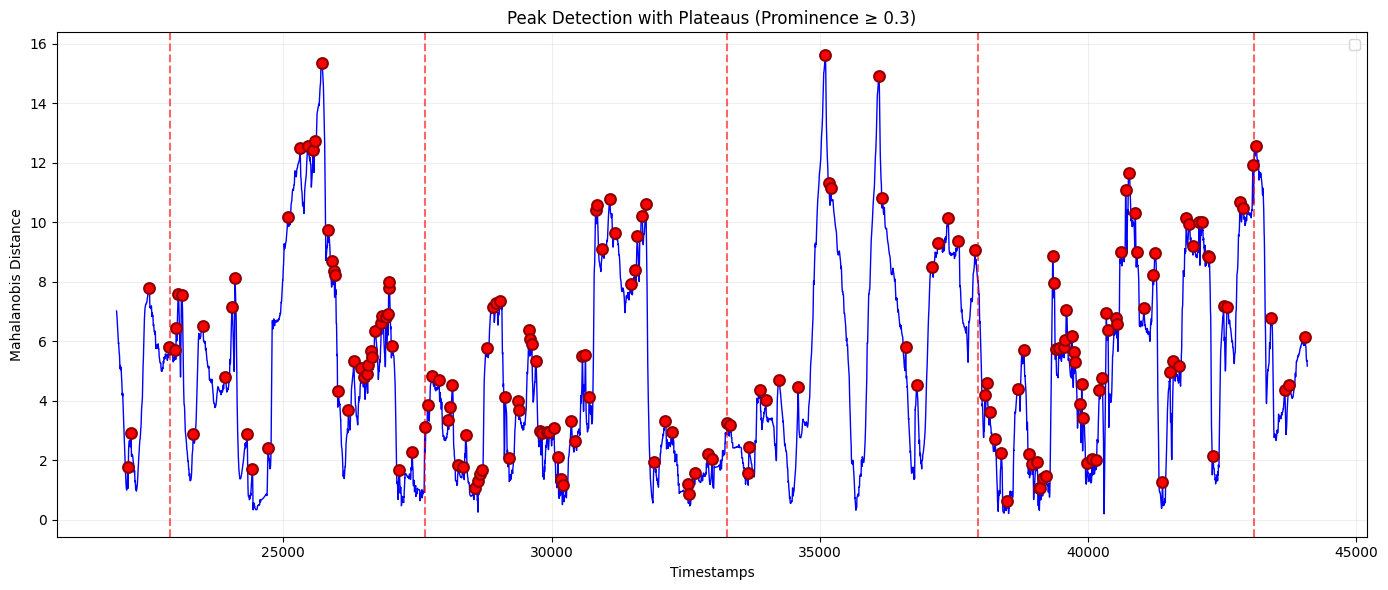

In [18]:
from scipy.signal import find_peaks

# Find peaks with plateau detection
peaks, properties = find_peaks(filtered_scores,
                               prominence=0.3,
                               width=50,
                               rel_height=0.5,
                               plateau_size=2)  # Minimum plateau width in samples

plt.figure(figsize=(14, 6))
plt.plot(filtered_timestamps, filtered_scores, 'b-', linewidth=1)

# Event lines
for cp in events[:5]:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.6)

# Plot peaks
plt.scatter(peak_timestamps, peak_values,
           color='red', s=60, zorder=5, edgecolors='darkred', linewidth=1.5)

# Handle plateaus
if 'plateaus' in properties:
    for i, (left_base, right_base) in enumerate(zip(properties['left_bases'],
                                                     properties['right_bases'])):
        # Peak plateau boundaries
        if 'plateaus' in properties and i < len(properties['plateaus']):
            plateau_start, plateau_end = properties['plateaus'][i]

            # Mark plateau region
            plt.axvspan(filtered_timestamps[plateau_start],
                       filtered_timestamps[plateau_end],
                       alpha=0.3, color='gold', label='Plateau' if i == 0 else '')

            # Mark boundaries with vertical lines
            plt.axvline(filtered_timestamps[plateau_start],
                       color='orange', linestyle=':', alpha=0.8, linewidth=2)
            plt.axvline(filtered_timestamps[plateau_end],
                       color='orange', linestyle=':', alpha=0.8, linewidth=2)

            # Mark base points where prominence is measured
            plt.plot(filtered_timestamps[left_base], filtered_scores[left_base],
                    'g^', markersize=8, label='Left Base' if i == 0 else '')
            plt.plot(filtered_timestamps[right_base], filtered_scores[right_base],
                    'gv', markersize=8, label='Right Base' if i == 0 else '')

# Add legend (avoid duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Timestamps')
plt.ylabel('Mahalanobis Distance')
plt.title(f'Peak Detection with Plateaus (Prominence ≥ 0.3)')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

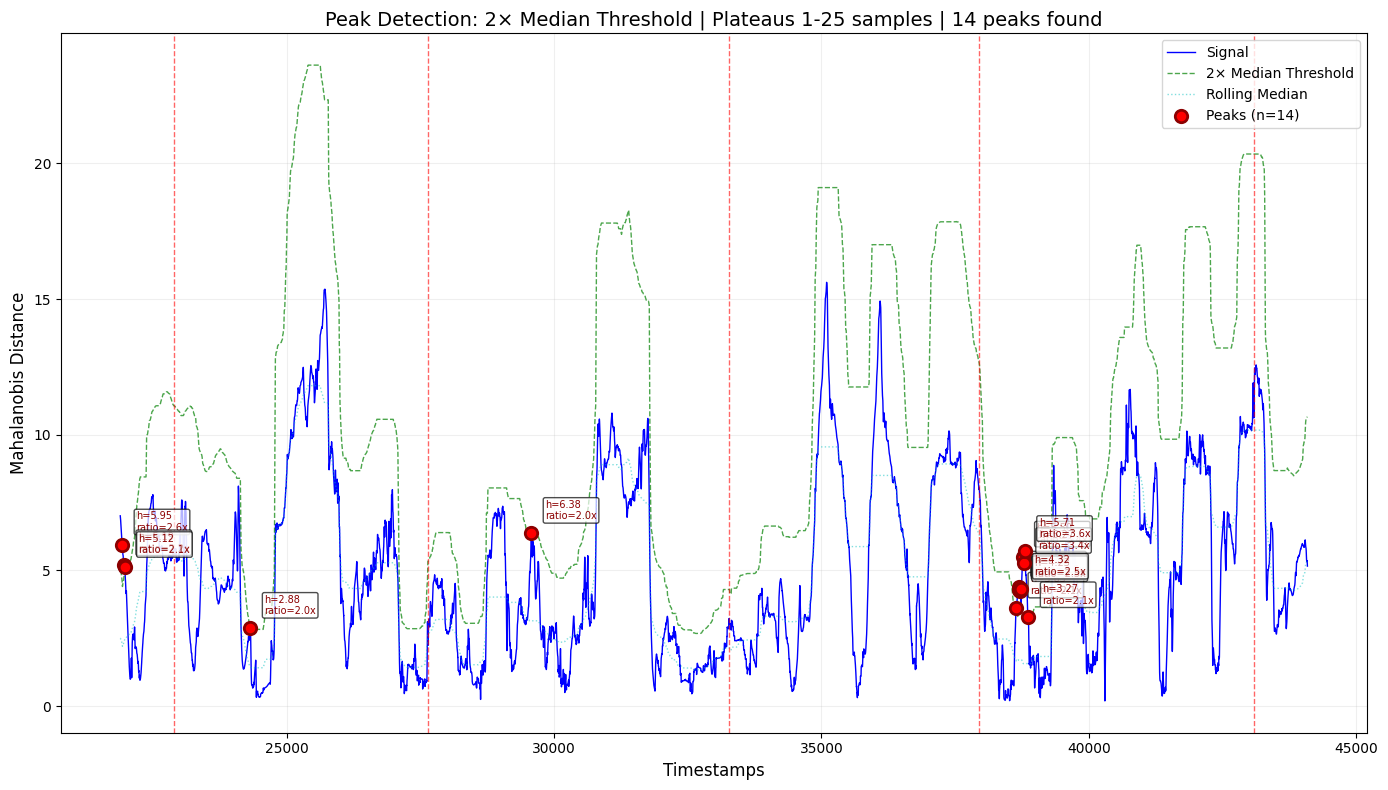


PEAK DETECTION WITH 2× MEDIAN THRESHOLD & PLATEAUS (1-25 samples)

Total peaks found: 14

Index  Timestamp    Height     2×Med      Ratio    Plateau    Width     
--------------------------------------------------------------------------------
0      21929.00     5.951      4.525      2.63     None       1.2       
1      21962.00     5.186      4.780      2.17     None       6.1       
2      21975.00     5.121      4.899      2.09     None       5.1       
3      24325.00     2.881      2.863      2.01     None       69.8      
4      29576.00     6.378      6.296      2.03     None       204.4     
5      38640.00     3.626      3.374      2.15     None       5.1       
6      38690.00     4.400      3.409      2.58     None       66.5      
7      38700.00     4.296      3.409      2.52     None       1.3       
8      38711.00     4.231      3.409      2.48     None       4.3       
9      38723.00     4.323      3.409      2.54     None       5.2       
10     38761.00     5.504

In [26]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# Filter data within time window
mask = (timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)
filtered_timestamps = timestamps[mask]
filtered_scores = scores_mahal[mask]

# ============================================
# ADAPTIVE THRESHOLD: 2× higher than median
# ============================================

# Calculate rolling median (window size can be adjusted)
window_size = 751  # Odd number for symmetrical window
median_filtered = np.zeros_like(filtered_scores)

# Simple moving median
for i in range(len(filtered_scores)):
    start = max(0, i - window_size // 2)
    end = min(len(filtered_scores), i + window_size // 2 + 1)
    median_filtered[i] = np.median(filtered_scores[start:end])

# Calculate threshold: peak must be >= 2× median
adaptive_threshold = median_filtered * 2

# ============================================
# FIND PEAKS WITH PLATEAU DETECTION
# ============================================

peaks, properties = find_peaks(
    filtered_scores,
    height=(adaptive_threshold, None),  # Min height = 2× median, no max
    prominence=None,  # We'll use height instead of prominence
    width=1,  # Minimum width in samples
    rel_height=0.5,  # Measure width at 50% of peak height
    plateau_size=(1, 25),  # Plateaus: min 1, max 25 samples
    distance=5  # Minimum 5 samples between peaks (optional)
)

# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(14, 8))

# Plot original signal
plt.plot(filtered_timestamps, filtered_scores, 'b-', linewidth=1, label='Signal')

# Plot adaptive threshold (2× median)
plt.plot(filtered_timestamps, adaptive_threshold, 'g--',
         linewidth=1, alpha=0.7, label='2× Median Threshold')

# Plot median baseline
plt.plot(filtered_timestamps, median_filtered, 'c:',
         linewidth=1, alpha=0.5, label='Rolling Median')

# Event vertical lines
for cp in events[:5]:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.6, linewidth=1)

# Scatter plot of peaks
peak_timestamps = filtered_timestamps[peaks]
peak_values = filtered_scores[peaks]
plt.scatter(peak_timestamps, peak_values,
           color='red', s=80, zorder=5,
           edgecolors='darkred', linewidth=2,
           label=f'Peaks (n={len(peaks)})')

# ============================================
# PLATEAU VISUALIZATION
# ============================================

if 'plateaus' in properties and len(properties['plateaus']) > 0:
    for i, (plateau_start, plateau_end) in enumerate(properties['plateaus']):
        start_time = filtered_timestamps[plateau_start]
        end_time = filtered_timestamps[plateau_end]
        plateau_height = filtered_scores[peaks[i]] if i < len(peaks) else None
        plateau_size_samples = plateau_end - plateau_start + 1

        # Only visualize plateaus within our size range
        if 1 <= plateau_size_samples <= 25:
            # Shade plateau region
            plt.axvspan(start_time, end_time, alpha=0.3, color='orange')

            # Mark boundaries
            plt.axvline(start_time, color='orange', linestyle=':',
                       alpha=0.8, linewidth=2)
            plt.axvline(end_time, color='orange', linestyle=':',
                       alpha=0.8, linewidth=2)

            # Add plateau annotation
            mid_time = (start_time + end_time) / 2
            plt.text(mid_time, plateau_height + 0.05,
                    f'P{i+1}: {plateau_size_samples}samples',
                    ha='center', fontsize=8, style='italic',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# ============================================
# DETAILED ANNOTATIONS
# ============================================

# Add height and plateau size info
for i, (peak_time, peak_val, idx) in enumerate(zip(peak_timestamps, peak_values, peaks)):
    # Calculate actual ratio to median
    med_at_peak = median_filtered[idx]
    ratio = peak_val / med_at_peak if med_at_peak > 0 else np.inf

    # Get plateau size if available
    plateau_info = ""
    if 'plateaus' in properties and i < len(properties['plateaus']):
        plateau_start, plateau_end = properties['plateaus'][i]
        plateau_size = plateau_end - plateau_start + 1
        plateau_info = f"\nplateau:{plateau_size}"

    plt.annotate(f'h={peak_val:.2f}\nratio={ratio:.1f}x{plateau_info}',
                xy=(peak_time, peak_val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=7,
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.xlabel('Timestamps', fontsize=12)
plt.ylabel('Mahalanobis Distance', fontsize=12)
plt.title(f'Peak Detection: 2× Median Threshold | Plateaus 1-25 samples | {len(peaks)} peaks found',
          fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================
# PRINT DETAILED RESULTS
# ============================================

print(f"\n{'='*80}")
print(f"PEAK DETECTION WITH 2× MEDIAN THRESHOLD & PLATEAUS (1-25 samples)")
print(f"{'='*80}")
print(f"\nTotal peaks found: {len(peaks)}")
print(f"\n{'Index':<6} {'Timestamp':<12} {'Height':<10} {'2×Med':<10} {'Ratio':<8} {'Plateau':<10} {'Width':<10}")
print(f"{'-'*80}")

for i, (idx, ts, val, med_val) in enumerate(zip(peaks, peak_timestamps, peak_values,
                                                  median_filtered[peaks])):
    ratio = val / med_val if med_val > 0 else np.inf
    plateau_size = "None"
    if 'plateaus' in properties and i < len(properties['plateaus']):
        p_start, p_end = properties['plateaus'][i]
        plateau_size = f"{p_end - p_start + 1} samples"

    width_val = properties['widths'][i] if 'widths' in properties else 0

    print(f"{i:<6} {ts:<12.2f} {val:<10.3f} {2*med_val:<10.3f} {ratio:<8.2f} {plateau_size:<10} {width_val:<10.1f}")

# Plateau summary
if 'plateaus' in properties and len(properties['plateaus']) > 0:
    print(f"\n{'='*80}")
    print(f"PLATEAU SUMMARY (sizes between 1-25 samples)")
    print(f"{'='*80}")

    for i, (start_idx, end_idx) in enumerate(properties['plateaus']):
        size = end_idx - start_idx + 1
        if 1 <= size <= 25:
            start_time = filtered_timestamps[start_idx]
            end_time = filtered_timestamps[end_idx]
            duration = end_time - start_time
            peak_height = filtered_scores[peaks[i]] if i < len(peaks) else None

            print(f"\nPlateau {i+1}:")
            print(f"  Time range: {start_time:.2f} → {end_time:.2f}")
            print(f"  Duration: {duration:.2f} time units")
            print(f"  Size: {size} samples")
            print(f"  Peak height: {peak_height:.3f}")
            print(f"  Flatness: {size/len(filtered_scores)*100:.1f}% of signal")

NameError: name 'ewma_vals' is not defined

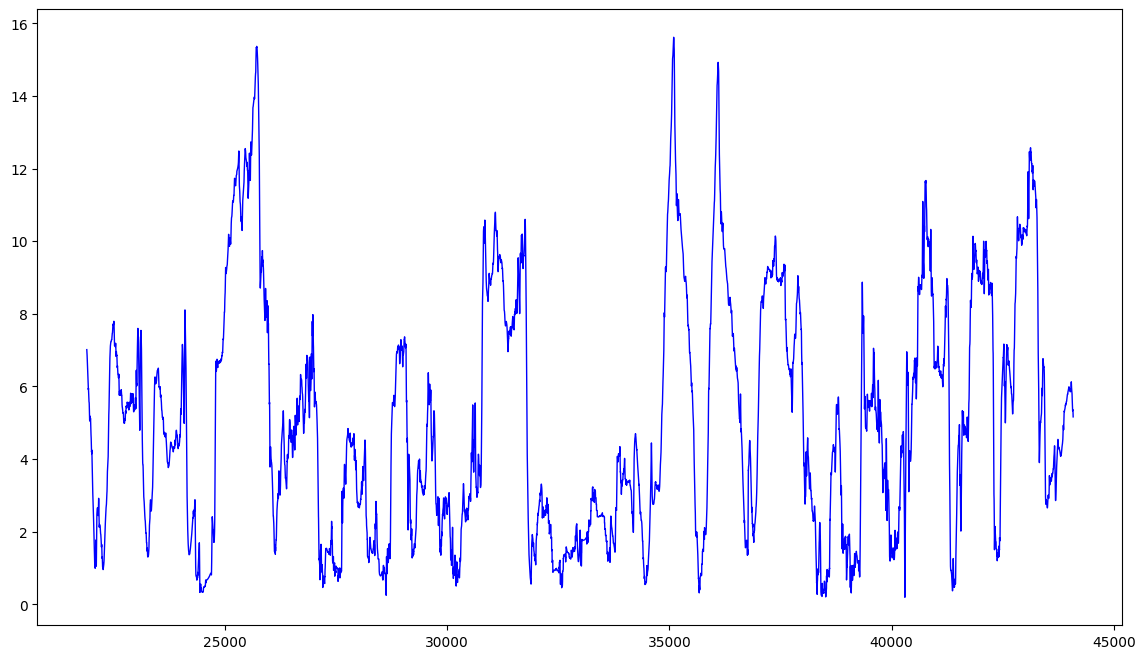

In [29]:
# Use EWMA for adaptive threshold with more weight on recent points
window_size = 10
alpha = 2 / (window_size + 1)  # Smoothing factor

significant_peaks = []
peak_indices = []
peak_values = []

# Initialize EWMA
ewma = filtered_scores[0]
ewma_std = 0

for i in range(len(filtered_scores)):
    if i > 0:
        # Update EWMA
        old_ewma = ewma
        ewma = alpha * filtered_scores[i] + (1 - alpha) * ewma

        # Update rolling standard deviation (simplified)
        if i < window_size:
            window_vals = filtered_scores[:i+1]
        else:
            window_vals = filtered_scores[i-window_size+1:i+1]
        ewma_std = np.std(window_vals)

        # Detect peak
        diff = filtered_scores[i] - ewma
        if diff > ewma_std * 2:  # Threshold: 2 standard deviations
            if len(peak_indices) == 0 or i - peak_indices[-1] > window_size/2:  # Avoid clusters
                significant_peaks.append((i, filtered_scores[i], diff))
                peak_indices.append(i)
                peak_values.append(filtered_scores[i])

peak_timestamps = filtered_timestamps[peak_indices]

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(filtered_timestamps, filtered_scores, 'b-', linewidth=1, label='Signal')
plt.plot(filtered_timestamps, [ewma_vals], 'g-', linewidth=2, alpha=0.7,
         label='EWMA (adaptive)')

# Plot threshold band
threshold_upper = [ewma_vals[i] + 2 * ewma_std_arr[i] for i in range(len(filtered_scores))]
plt.fill_between(filtered_timestamps, ewma_vals, threshold_upper,
                  alpha=0.2, color='green', label='EWMA + 2σ')

for cp in events[:5]:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.6)

plt.scatter(peak_timestamps, peak_values, color='red', s=80, zorder=5,
           edgecolors='darkred', linewidth=2, label=f'Peaks (n={len(peak_indices)})')

plt.xlabel('Timestamps')
plt.ylabel('Mahalanobis Distance')
plt.title(f'EWMA Peak Detection (window={window_size})')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import silhouette_score
from scipy.signal import find_peaks
import numpy as np

def auto_tune_find_peaks(signal, param_ranges=None):
    """
    Automatically find optimal parameters using grid search
    """
    if param_ranges is None:
        param_ranges = {
            'prominence': np.linspace(np.percentile(signal, 50),
                                     np.percentile(signal, 95), 10),
            'distance': np.arange(5, min(50, len(signal)//10), 5),
            'width': np.arange(1, 10, 1),
            'plateau_size_min': [1, 2, 3, 5],
            'plateau_size_max': [5, 10, 15, 25]
        }

    best_params = None
    best_score = -np.inf
    results = []

    # Grid search
    for prom in param_ranges['prominence']:
        for dist in param_ranges['distance']:
            for width in param_ranges['width']:
                for p_min in param_ranges['plateau_size_min']:
                    for p_max in param_ranges['plateau_size_max']:
                        if p_min >= p_max:
                            continue

                        try:
                            peaks, props = find_peaks(signal,
                                                     prominence=prom,
                                                     distance=dist,
                                                     width=(width, None),
                                                     plateau_size=(p_min, p_max))

                            # Scoring criteria
                            if len(peaks) == 0:
                                score = -100
                            else:
                                # Multi-criteria score
                                # 1. Number of peaks (not too many, not too few)
                                n_peaks_score = -abs(len(peaks) - len(signal)/200)  # Expect ~1 peak per 200 samples

                                # 2. Prominence consistency
                                prom_consistency = -np.std(props['prominences']) if 'prominences' in props else 0

                                # 3. Peak separation (good if evenly spaced)
                                if len(peaks) > 1:
                                    spacing_std = np.std(np.diff(peaks))
                                    spacing_score = -spacing_std / (len(signal)/len(peaks))
                                else:
                                    spacing_score = 0

                                # 4. Peak heights (should be high relative to baseline)
                                height_score = np.mean(signal[peaks]) / np.percentile(signal, 50)

                                score = (n_peaks_score * 0.3 +
                                        prom_consistency * 0.2 +
                                        spacing_score * 0.3 +
                                        height_score * 0.2)

                            results.append({
                                'prominence': prom,
                                'distance': dist,
                                'width': width,
                                'plateau_size': (p_min, p_max),
                                'n_peaks': len(peaks),
                                'score': score
                            })

                            if score > best_score:
                                best_score = score
                                best_params = {
                                    'prominence': prom,
                                    'distance': dist,
                                    'width': (width, None),
                                    'plateau_size': (p_min, p_max),
                                    'rel_height': 0.5
                                }
                        except:
                            continue

    # Sort results by score
    results.sort(key=lambda x: x['score'], reverse=True)

    print("\n" + "="*60)
    print("TOP 5 PARAMETER COMBINATIONS")
    print("="*60)
    for i, res in enumerate(results[:5]):
        print(f"\n{i+1}. Score: {res['score']:.2f} | Peaks: {res['n_peaks']}")
        print(f"   prominence={res['prominence']:.3f}, distance={res['distance']}, "
              f"width={res['width']}, plateau={res['plateau_size']}")

    return best_params, best_score, results

# Run auto-tuning
best_params, best_score, all_results = auto_tune_find_peaks(filtered_scores)

# Apply best parameters
peaks, properties = find_peaks(filtered_scores, **best_params)

print(f"\n✅ Best parameters found (score: {best_score:.2f})")
print(f"   {best_params}")
print(f"   → Found {len(peaks)} peaks")


TOP 5 PARAMETER COMBINATIONS

1. Score: -29.15 | Peaks: 15
   prominence=4.432, distance=5, width=1, plateau=(1, 5)

2. Score: -29.15 | Peaks: 15
   prominence=4.432, distance=5, width=1, plateau=(1, 10)

3. Score: -29.15 | Peaks: 15
   prominence=4.432, distance=5, width=1, plateau=(1, 15)

4. Score: -29.15 | Peaks: 15
   prominence=4.432, distance=5, width=1, plateau=(1, 25)

5. Score: -29.15 | Peaks: 15
   prominence=4.432, distance=5, width=2, plateau=(1, 5)

✅ Best parameters found (score: -29.15)
   {'prominence': np.float64(4.432186659596974), 'distance': np.int64(5), 'width': (np.int64(1), None), 'plateau_size': (1, 5), 'rel_height': 0.5}
   → Found 15 peaks


# good peaks

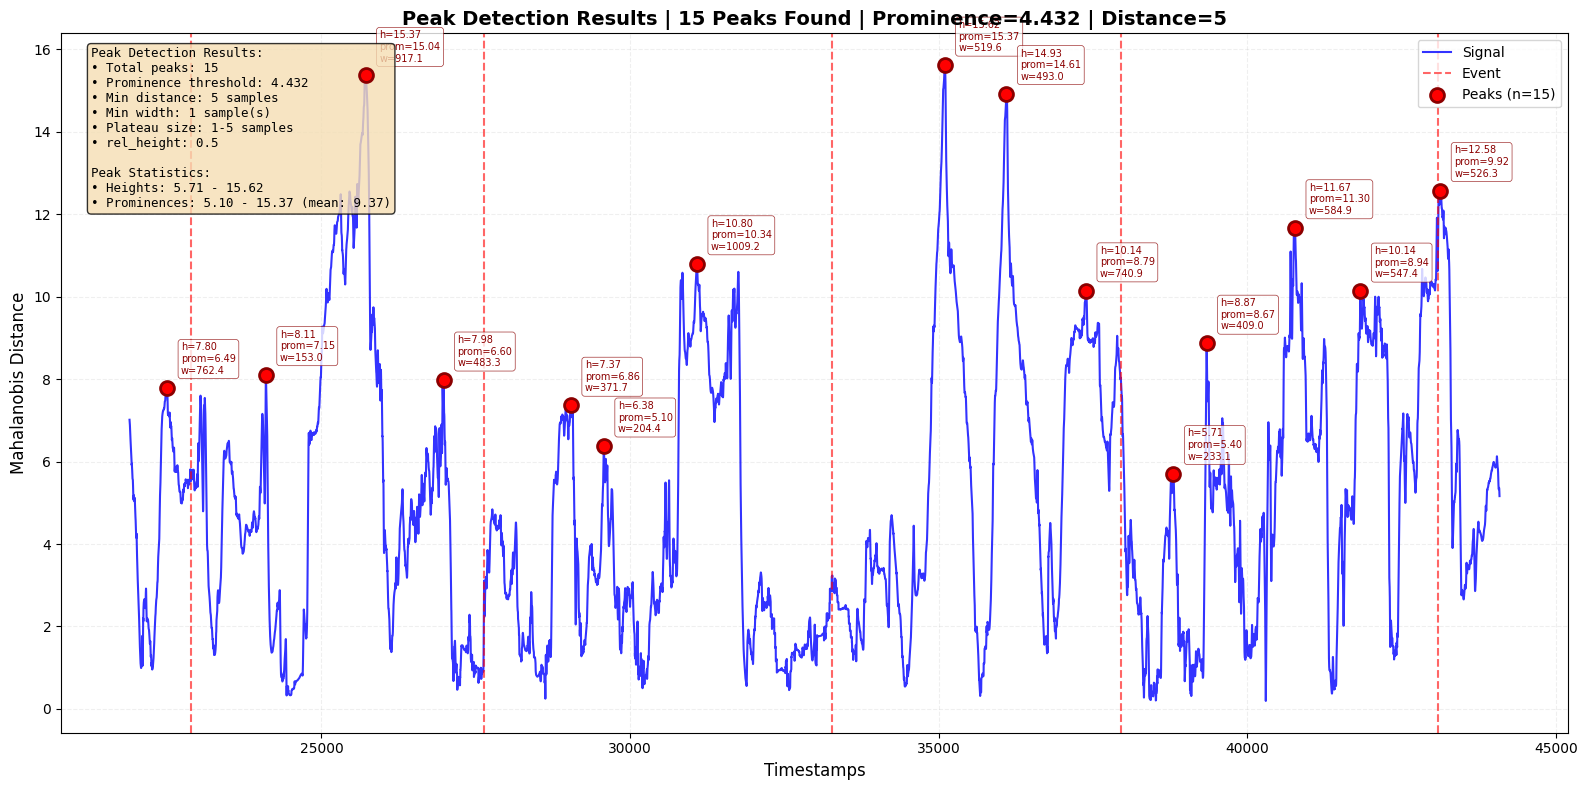


DETAILED PEAK DETECTION RESULTS

Parameters used:
  prominence     : 4.432186659596974
  distance       : 5
  width          : (np.int64(1), None)
  plateau_size   : (1, 5)
  rel_height     : 0.5

Index  Timestamp    Height     Prominence   Width      Plateau    Left Base  Right Base
----------------------------------------------------------------------------------------------------
0      22501.00     7.796      6.486        762.4      None       368        1370      
1      24100.00     8.109      7.153        153.0      None       368        2545      
2      25716.00     15.367     15.041       917.1      None       2545       6736      
3      26979.00     7.979      6.600        483.3      None       4242       6736      
4      29042.00     7.367      6.865        371.7      None       6736       8311      
5      29576.00     6.378      5.101        204.4      None       7321       8311      
6      31084.00     10.799     10.343       1009.2     None       6736       10685   

In [32]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# Your parameters
params = {
    'prominence': np.float64(4.432186659596974),
    'distance': np.int64(5),
    'width': (np.int64(1), None),
    'plateau_size': (1, 5),
    'rel_height': 0.5
}

# Filter data within time window
mask = (timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)
filtered_timestamps = timestamps[mask]
filtered_scores = scores_mahal[mask]

# Apply find_peaks with your parameters
peaks, properties = find_peaks(
    filtered_scores,
    prominence=params['prominence'],
    distance=params['distance'],
    width=params['width'],
    plateau_size=params['plateau_size'],
    rel_height=params['rel_height']
)

# ============================================
# PLOTTING
# ============================================

plt.figure(figsize=(16, 8))

# Plot the signal
plt.plot(filtered_timestamps, filtered_scores, 'b-', linewidth=1.5, label='Signal', alpha=0.8)

# Plot vertical lines for events
for cp in events[:5]:
    plt.axvline(cp, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Event' if cp == events[0] else '')

# Plot peaks as scatter plot (red dots)
peak_timestamps = filtered_timestamps[peaks]
peak_values = filtered_scores[peaks]
plt.scatter(peak_timestamps, peak_values,
           color='red', s=100, zorder=5,
           edgecolors='darkred', linewidth=2,
           label=f'Peaks (n={len(peaks)})')

# ============================================
# PLATEAU VISUALIZATION
# ============================================

if 'plateaus' in properties and len(properties['plateaus']) > 0:
    for i, (plateau_start_idx, plateau_end_idx) in enumerate(properties['plateaus']):
        # Get timestamps for plateau boundaries
        start_time = filtered_timestamps[plateau_start_idx]
        end_time = filtered_timestamps[plateau_end_idx]
        plateau_size = plateau_end_idx - plateau_start_idx + 1

        # Get peak height for this plateau (if available)
        if i < len(peaks):
            peak_height = filtered_scores[peaks[i]]
        else:
            peak_height = np.mean(filtered_scores[plateau_start_idx:plateau_end_idx+1])

        # Shade plateau region
        plt.axvspan(start_time, end_time, alpha=0.25, color='orange', label='Plateau' if i == 0 else '')

        # Mark plateau boundaries with vertical dotted lines
        plt.axvline(start_time, color='orange', linestyle=':', alpha=0.8, linewidth=2)
        plt.axvline(end_time, color='orange', linestyle=':', alpha=0.8, linewidth=2)

        # Add plateau annotation
        mid_time = (start_time + end_time) / 2
        plt.text(mid_time, peak_height + (peak_height * 0.05),
                f'Plateau\n{plateau_size} samples',
                ha='center', fontsize=8, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

        # Print plateau details
        print(f"Plateau {i+1}: samples {plateau_start_idx}-{plateau_end_idx} "
              f"(size={plateau_size}), time: {start_time:.2f}-{end_time:.2f}")

# ============================================
# ADD PEAK ANNOTATIONS
# ============================================

for i, (idx, ts, val) in enumerate(zip(peaks, peak_timestamps, peak_values)):
    # Get prominence for this peak
    prom = properties['prominences'][i] if 'prominences' in properties else params['prominence']

    # Get width for this peak
    width_val = properties['widths'][i] if 'widths' in properties else 0

    # Get plateau size if this peak has a plateau
    plateau_info = ""
    if 'plateaus' in properties and i < len(properties['plateaus']):
        p_start, p_end = properties['plateaus'][i]
        plateau_size = p_end - p_start + 1
        plateau_info = f"\nplateau:{plateau_size}"

    # Add text annotation
    plt.annotate(f'h={val:.2f}\nprom={prom:.2f}\nw={width_val:.1f}{plateau_info}',
                xy=(ts, val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=7,
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8,
                         edgecolor='darkred', linewidth=0.5))

# ============================================
# ADD STATISTICS BOX
# ============================================

stats_text = f"""Peak Detection Results:
• Total peaks: {len(peaks)}
• Prominence threshold: {params['prominence']:.3f}
• Min distance: {params['distance']} samples
• Min width: {params['width'][0]} sample(s)
• Plateau size: {params['plateau_size'][0]}-{params['plateau_size'][1]} samples
• rel_height: {params['rel_height']}

Peak Statistics:
• Heights: {peak_values.min():.2f} - {peak_values.max():.2f}
• Prominences: {properties['prominences'].min():.2f} - {properties['prominences'].max():.2f} (mean: {properties['prominences'].mean():.2f})"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         family='monospace')

# ============================================
# FORMATTING
# ============================================

plt.xlabel('Timestamps', fontsize=12)
plt.ylabel('Mahalanobis Distance', fontsize=12)
plt.title(f'Peak Detection Results | {len(peaks)} Peaks Found | Prominence={params["prominence"]:.3f} | Distance={params["distance"]}',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================
# PRINT DETAILED TABLE
# ============================================

print("\n" + "="*100)
print("DETAILED PEAK DETECTION RESULTS")
print("="*100)
print(f"\nParameters used:")
for key, value in params.items():
    print(f"  {key:15}: {value}")

print(f"\n{'Index':<6} {'Timestamp':<12} {'Height':<10} {'Prominence':<12} {'Width':<10} {'Plateau':<10} {'Left Base':<10} {'Right Base':<10}")
print("-"*100)

for i, (idx, ts, val) in enumerate(zip(peaks, peak_timestamps, peak_values)):
    prom = properties['prominences'][i]
    width_val = properties['widths'][i]

    plateau_info = "None"
    left_base = "N/A"
    right_base = "N/A"

    if 'plateaus' in properties and i < len(properties['plateaus']):
        p_start, p_end = properties['plateaus'][i]
        plateau_info = f"{p_end-p_start+1} samples"

    if 'left_bases' in properties and i < len(properties['left_bases']):
        left_base = f"{properties['left_bases'][i]}"
    if 'right_bases' in properties and i < len(properties['right_bases']):
        right_base = f"{properties['right_bases'][i]}"

    print(f"{i:<6} {ts:<12.2f} {val:<10.3f} {prom:<12.3f} {width_val:<10.1f} {plateau_info:<10} {left_base:<10} {right_base:<10}")

# ============================================
# OPTIONAL: SAVE RESULTS
# ============================================

# Uncomment to save the plot
# plt.savefig('peak_detection_results.png', dpi=150, bbox_inches='tight')

# Uncomment to save peak data to CSV
# import pandas as pd
# results_df = pd.DataFrame({
#     'peak_index': peaks,
#     'timestamp': peak_timestamps,
#     'height': peak_values,
#     'prominence': properties['prominences'],
#     'width': properties['widths'],
# })
# results_df.to_csv('detected_peaks.csv', index=False)
# print("\n✅ Peak data saved to 'detected_peaks.csv'")

# bayes opt with peaks

In [33]:
# Bayesian Optimization Pipeline for Regime Change Divergence Detection
# Full: STEP, WINDOW, and all find_peaks parameters

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

# ============================================================
# CONFIG
# ============================================================

EVENT_MATCH_THRESHOLD = 50
N_CALLS = 50  # Increased because more parameters
N_INITIAL_POINTS = 15
RANDOM_STATE = 42
OUTPUT_DIR = 'bayes_regime_search_full_run2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# DISTANCE METRICS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)

def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)

def relative_change(left, right):
    eps = 1e-8
    rel = np.abs(right - left) / (np.abs(left) + eps)
    return np.mean(rel)

# ============================================================
# FEATURE EXTRACTION (define your extract_features function)
# ============================================================

def extract_features(window):
    """
    Extract features from a window of data.
    MODIFY THIS BASED ON YOUR ACTUAL FEATURE EXTRACTION.
    """
    # Placeholder - replace with your actual feature extraction
    features = [
        np.mean(window),
        np.std(window),
        np.median(window),
        np.max(window) - np.min(window),
        np.percentile(window, 25),
        np.percentile(window, 75),
        np.sum(np.abs(np.diff(window))),  # Total variation
        np.mean(np.abs(np.diff(window)))  # Average slope
    ]
    return np.array(features), None

# ============================================================
# EVALUATION
# ============================================================

def evaluate_minima(minima, events):
    """
    Evaluate detected minima against ground truth events.
    Uses ALL events, not just first 5.
    """
    tp = 0
    fp = 0
    matched_minima = set()

    for ev in events:
        if len(minima) == 0:
            continue
        distances = np.abs(minima - ev)
        idx = np.argmin(distances)
        if distances[idx] <= EVENT_MATCH_THRESHOLD:
            tp += 1
            matched_minima.add(idx)

    for i, peak in enumerate(minima):
        if i not in matched_minima:
            distances = np.abs(events - peak)
            if len(distances) == 0 or np.min(distances) > EVENT_MATCH_THRESHOLD:
                fp += 1

    fn = len(events) - tp

    # Calculate additional metrics
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
    accuracy = tp / (tp + fp + fn + 1e-8)

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1_score),
        'accuracy': float(accuracy),
        'score': float(tp - fp * 0.1)  # TP weighted, small penalty for FP
    }

# ============================================================
# SEARCH SPACE - All find_peaks parameters included
# ============================================================

space = [
    # Original parameters
    Integer(20, 500, name='WINDOW'),
    Integer(5, 100, name='STEP'),

    # find_peaks parameters
    Real(0.1, 10.0, name='prominence'),      # Minimum prominence
    Integer(1, 50, name='distance'),          # Min distance between peaks (samples)
    Integer(1, 20, name='width_min'),         # Minimum width (samples)
    Integer(1, 50, name='width_max'),         # Maximum width (samples) - None means no max
    Real(0.1, 1.0, name='rel_height'),        # Relative height for width calculation
    Integer(1, 30, name='plateau_min'),       # Minimum plateau size
    Integer(5, 100, name='plateau_max'),      # Maximum plateau size
    Real(0.01, 2.0, name='threshold'),        # Vertical distance to neighbors
    Integer(1, 20, name='wlen')               # Window length for prominence calculation
]

# ============================================================
# GLOBALS
# ============================================================

trial_counter = 0
results = []
evaluated_points = []

# ============================================================
# HEATMAP UPDATE (simplified - 2D projection)
# ============================================================

def update_heatmap():
    """Creates a 2D heatmap projection (WINDOW vs STEP) colored by best TP across other params"""
    if len(evaluated_points) < 4:
        return

    from scipy.interpolate import griddata

    window_range = np.linspace(20, 500, 100)
    step_range = np.linspace(5, 100, 100)
    W_grid, S_grid = np.meshgrid(window_range, step_range)

    points = np.array([[p['WINDOW'], p['STEP']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    grid_scores = griddata(points, scores, (W_grid, S_grid), method='linear', fill_value=-1)

    fig, ax = plt.subplots(figsize=(14, 10))

    im = ax.imshow(grid_scores, extent=[20, 500, 5, 100],
                   origin='lower', aspect='auto', cmap='viridis', alpha=0.85)

    plt.colorbar(im, ax=ax, label='TP Score (TP - 0.1*FP)')

    # Plot evaluated points
    ax.scatter(points[:, 0], points[:, 1], c='red', s=60, edgecolors='black', linewidths=1, zorder=5)

    # Label best points
    best_idx = np.argmax(scores)
    ax.scatter(points[best_idx, 0], points[best_idx, 1],
              c='red', s=300, marker='*', edgecolors='white', linewidths=2, zorder=6)

    ax.set_xlabel('Window Size')
    ax.set_ylabel('Step Size')
    ax.set_title(f'Search Progress: Best TP={scores[best_idx]:.1f} ({len(evaluated_points)} trials)')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'current_heatmap.png'), bbox_inches='tight', dpi=150)
    plt.close(fig)

# ============================================================
# OBJECTIVE FUNCTION
# ============================================================

@use_named_args(space)
def objective(WINDOW, STEP, prominence, distance, width_min, width_max,
              rel_height, plateau_min, plateau_max, threshold, wlen):
    global trial_counter

    trial_counter += 1
    print(f'\n{"="*60}')
    print(f'Trial {trial_counter}:')
    print(f'  Window={WINDOW}, Step={STEP}')
    print(f'  Prom={prominence:.2f}, Dist={distance}, Width=({width_min},{width_max})')
    print(f'  RelH={rel_height:.2f}, Plateau=({plateau_min},{plateau_max})')
    print(f'  Threshold={threshold:.2f}, WLEN={wlen}')
    print(f'{"="*60}')

    # First pass: collect features
    all_features = []
    feature_timestamps = []

    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]
        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)
        all_features.append(left_feat)
        all_features.append(right_feat)
        feature_timestamps.append(t)

    if len(all_features) == 0:
        print("  No features extracted, returning -1")
        return -1.0

    all_features = np.array(all_features)

    # Covariance matrix with regularization
    cov = np.cov(all_features.T)
    if np.isnan(cov).any() or np.isinf(cov).any():
        cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

    trace = np.trace(cov)
    reg_strength = 1e-6 * trace / max(cov.shape[0], 1) if trace > 0 else 1e-6
    cov_reg = cov + np.eye(cov.shape[0]) * reg_strength
    cov_inv = pinv(cov_reg)

    # Second pass: calculate Mahalanobis scores
    timestamps = []
    scores_mahal = []

    for t in range(WINDOW, len(data) - WINDOW, STEP):
        left_window = data[t-WINDOW:t]
        right_window = data[t:t+WINDOW]
        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        try:
            s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
        except:
            s_mahal = l2_distance(left_feat, right_feat)  # Fallback to L2

        timestamps.append(t)
        scores_mahal.append(s_mahal)

    timestamps = np.array(timestamps)
    scores_mahal = np.array(scores_mahal)

    # Normalize scores for better peak detection
    scores_norm = (scores_mahal - scores_mahal.min()) / (scores_mahal.max() - scores_mahal.min() + 1e-8)

    # Find local minima (regime change points) using ALL find_peaks parameters
    try:
        # Handle width parameter (None means no max)
        width_param = None if width_max == 0 else (width_min, width_max)

        # Handle plateau_size
        plateau_size_param = (plateau_min, plateau_max) if plateau_max > plateau_min else None

        minima_idx, properties = find_peaks(
            -scores_norm,  # Negative for minima detection
            prominence=prominence,
            distance=distance,
            width=width_param,
            rel_height=rel_height,
            plateau_size=plateau_size_param,
            threshold=threshold,
            wlen=wlen if wlen > 0 else None
        )

        # Also try with raw scores if normalized fails to find peaks
        if len(minima_idx) == 0:
            minima_idx, properties = find_peaks(
                -scores_mahal,
                prominence=prominence * np.std(scores_mahal),
                distance=distance,
                width=width_param,
                rel_height=rel_height,
                plateau_size=plateau_size_param,
                threshold=threshold * np.std(scores_mahal),
                wlen=wlen if wlen > 0 else None
            )

    except Exception as e:
        print(f"  Error in find_peaks: {e}")
        minima_idx = []

    minima_timestamps = timestamps[minima_idx]

    # Evaluate against ALL events (not just first 5)
    metrics = evaluate_minima(minima_timestamps, events)

    print(f'\n  Results: TP={metrics["tp"]}/{len(events)} events')
    print(f'          FP={metrics["fp"]}, FN={metrics["fn"]}')
    print(f'          Precision={metrics["precision"]:.3f}, Recall={metrics["recall"]:.3f}')
    print(f'          F1={metrics["f1_score"]:.3f}, Score={metrics["score"]:.2f}')

    # Store results
    result = {
        'trial': trial_counter,
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        'prominence': float(prominence),
        'distance': int(distance),
        'width_min': int(width_min),
        'width_max': int(width_max) if width_max > 0 else None,
        'rel_height': float(rel_height),
        'plateau_min': int(plateau_min),
        'plateau_max': int(plateau_max),
        'threshold': float(threshold),
        'wlen': int(wlen) if wlen > 0 else None,
        'n_peaks': len(minima_idx),
        **metrics
    }
    results.append(result)
    evaluated_points.append({
        'trial': trial_counter,
        'WINDOW': int(WINDOW),
        'STEP': int(STEP),
        'score': metrics['score']
    })

    # Save results incrementally
    with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    # Update visualization
    update_heatmap()

    # Return negative score for minimization
    return -metrics['score']

# ============================================================
# PLOT BEST RESULT VISUALIZATION
# ============================================================

def plot_best_result(best_params, timestamps, scores_mahal, minima_timestamps, events):
    """Plot the best result with all events shown"""

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Plot 1: Mahalanobis scores with detected minima
    ax1 = axes[0]
    ax1.plot(timestamps, scores_mahal, 'b-', linewidth=1.5, alpha=0.8, label='Mahalanobis Distance')
    ax1.scatter(minima_timestamps,
                [scores_mahal[np.where(timestamps == t)[0][0]] if len(np.where(timestamps == t)[0]) > 0 else 0
                 for t in minima_timestamps],
                color='red', s=100, zorder=5, marker='o', edgecolors='darkred', linewidth=2,
                label=f'Detected Regime Changes (n={len(minima_timestamps)})')

    # Mark all ground truth events
    for ev in events:
        ax1.axvline(ev, color='green', linestyle='--', alpha=0.6, linewidth=1.5,
                   label='Ground Truth Event' if ev == events[0] else '')

    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('Mahalanobis Distance')
    ax1.set_title(f'Regime Change Detection - Best Parameters (F1={best_params["f1_score"]:.3f})')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.2)

    # Plot 2: Normalized scores with plateaus and peaks
    ax2 = axes[1]
    scores_norm = (scores_mahal - scores_mahal.min()) / (scores_mahal.max() - scores_mahal.min() + 1e-8)
    ax2.plot(timestamps, -scores_norm, 'b-', linewidth=1.5, alpha=0.8, label='Negative Normalized Score')

    # Re-run find_peaks with best parameters to get plateau info
    width_param = None if best_params['width_max'] == 0 else (best_params['width_min'], best_params['width_max'])
    plateau_param = (best_params['plateau_min'], best_params['plateau_max']) if best_params['plateau_max'] > best_params['plateau_min'] else None

    minima_idx, properties = find_peaks(
        -scores_norm,
        prominence=best_params['prominence'],
        distance=best_params['distance'],
        width=width_param,
        rel_height=best_params['rel_height'],
        plateau_size=plateau_param,
        threshold=best_params['threshold'],
        wlen=best_params['wlen']
    )

    # Mark plateaus
    if 'plateaus' in properties and len(properties['plateaus']) > 0:
        for i, (start, end) in enumerate(properties['plateaus']):
            if start < len(timestamps) and end < len(timestamps):
                ax2.axvspan(timestamps[start], timestamps[end], alpha=0.3, color='orange', label='Plateau' if i == 0 else '')
                ax2.axvline(timestamps[start], color='orange', linestyle=':', alpha=0.8)
                ax2.axvline(timestamps[end], color='orange', linestyle=':', alpha=0.8)

    ax2.scatter(timestamps[minima_idx], -scores_norm[minima_idx],
               color='red', s=80, zorder=5, marker='o')

    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('Negative Normalized Score')
    ax2.set_title('Peak Detection Details (Negative scores for minima detection)')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'best_result_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# FINAL HEATMAP AND DETAILED ANALYSIS
# ============================================================

def final_analysis():
    """Generate comprehensive final analysis and visualizations"""

    if len(evaluated_points) < 4:
        print("Not enough points for detailed analysis")
        return

    from scipy.interpolate import griddata

    # 2D Heatmap (WINDOW vs STEP)
    window_range = np.linspace(20, 500, 100)
    step_range = np.linspace(5, 100, 100)
    W_grid, S_grid = np.meshgrid(window_range, step_range)

    points = np.array([[p['WINDOW'], p['STEP']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    grid_scores = griddata(points, scores, (W_grid, S_grid), method='linear', fill_value=-1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Heatmap 1: TP Score
    ax1 = axes[0]
    im1 = ax1.imshow(grid_scores, extent=[20, 500, 5, 100],
                     origin='lower', aspect='auto', cmap='plasma', alpha=0.85)
    plt.colorbar(im1, ax=ax1, label='Score (TP - 0.1*FP)')

    best_idx = np.argmax(scores)
    for i, (w, s) in enumerate(points):
        color = 'red' if i == best_idx else 'white'
        size = 200 if i == best_idx else 60
        marker = '*' if i == best_idx else 'o'
        ax1.scatter(w, s, c=color, s=size, marker=marker, edgecolors='black', linewidths=1, zorder=5)

    ax1.set_xlabel('Window Size', fontsize=12)
    ax1.set_ylabel('Step Size', fontsize=12)
    ax1.set_title(f'Score Heatmap (Best: {scores[best_idx]:.1f})', fontsize=12)

    # Heatmap 2: F1 Score if available
    ax2 = axes[1]
    f1_scores = np.array([r['f1_score'] for r in results if 'f1_score' in r])
    if len(f1_scores) == len(scores):
        grid_f1 = griddata(points, f1_scores, (W_grid, S_grid), method='linear', fill_value=0)
        im2 = ax2.imshow(grid_f1, extent=[20, 500, 5, 100],
                         origin='lower', aspect='auto', cmap='viridis', alpha=0.85)
        plt.colorbar(im2, ax=ax2, label='F1 Score')

        for i, (w, s) in enumerate(points):
            color = 'red' if i == best_idx else 'white'
            size = 200 if i == best_idx else 60
            marker = '*' if i == best_idx else 'o'
            ax2.scatter(w, s, c=color, s=size, marker=marker, edgecolors='black', linewidths=1, zorder=5)

        ax2.set_xlabel('Window Size', fontsize=12)
        ax2.set_ylabel('Step Size', fontsize=12)
        ax2.set_title(f'F1 Score Heatmap (Best: {f1_scores[best_idx]:.3f})', fontsize=12)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'final_heatmaps.png'), bbox_inches='tight', dpi=150)
    plt.close()

    # Parameter importance analysis
    print("\n" + "="*80)
    print("PARAMETER CORRELATION ANALYSIS")
    print("="*80)

    # Calculate correlation between parameters and score
    param_names = ['WINDOW', 'STEP', 'prominence', 'distance', 'width_min',
                   'rel_height', 'plateau_min', 'threshold', 'wlen']

    correlations = {}
    for param in param_names:
        if param in results[0]:
            param_vals = np.array([r[param] for r in results])
            scores = np.array([r['score'] for r in results])
            corr = np.corrcoef(param_vals, scores)[0, 1]
            correlations[param] = corr
            print(f"{param:15}: {corr:+.3f}")

    # Best parameter summary
    print("\n" + "="*80)
    print("TOP 5 TRIALS")
    print("="*80)

    sorted_results = sorted(results, key=lambda x: x['score'], reverse=True)
    for i, res in enumerate(sorted_results[:5]):
        print(f"\n{i+1}. Trial {res['trial']}: Score={res['score']:.2f} | "
              f"TP={res['tp']}, FP={res['fp']}, FN={res['fn']}")
        print(f"   W={res['WINDOW']}, S={res['STEP']}, Prom={res.get('prominence',0):.2f}, "
              f"Dist={res.get('distance',0)}, Width=({res.get('width_min',0)},{res.get('width_max',0)})")
        print(f"   Plateau=({res.get('plateau_min',0)},{res.get('plateau_max',0)}), "
              f"RelH={res.get('rel_height',0):.2f}, Thresh={res.get('threshold',0):.2f}")

# ============================================================
# RUN OPTIMIZATION
# ============================================================

print(f"\n{'='*60}")
print(f"BAYESIAN OPTIMIZATION WITH FULL FIND_PEAKS PARAMETERS")
print(f"{'='*60}")
print(f"Total trials: {N_CALLS}")
print(f"Initial points: {N_INITIAL_POINTS}")
print(f"Search space dimensions: {len(space)}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"{'='*60}\n")

# Run optimization
optimization_result = gp_minimize(
    objective,
    space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_POINTS,
    random_state=RANDOM_STATE,
    verbose=False
)

# ============================================================
# RESULTS SUMMARY
# ============================================================

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

# Find best result
best_idx = np.argmax([r['score'] for r in results])
best = results[best_idx]

print(f"\n🎯 BEST PARAMETERS FOUND:")
print(f"{'='*60}")
print(f"  WINDOW:        {best['WINDOW']}")
print(f"  STEP:          {best['STEP']}")
print(f"\n  find_peaks parameters:")
print(f"  prominence:    {best.get('prominence', 'N/A'):.3f}")
print(f"  distance:      {best.get('distance', 'N/A')}")
print(f"  width:         ({best.get('width_min', 'N/A')}, {best.get('width_max', 'N/A')})")
print(f"  rel_height:    {best.get('rel_height', 'N/A'):.2f}")
print(f"  plateau_size:  ({best.get('plateau_min', 'N/A')}, {best.get('plateau_max', 'N/A')})")
print(f"  threshold:     {best.get('threshold', 'N/A'):.3f}")
print(f"  wlen:          {best.get('wlen', 'N/A')}")
print(f"\n  Performance:")
print(f"  TP:            {best['tp']} / {len(events)} events")
print(f"  FP:            {best['fp']}")
print(f"  FN:            {best['fn']}")
print(f"  Precision:     {best.get('precision', 0):.3f}")
print(f"  Recall:        {best.get('recall', 0):.3f}")
print(f"  F1 Score:      {best.get('f1_score', 0):.3f}")
print(f"  Accuracy:      {best.get('accuracy', 0):.3f}")
print(f"  Score:         {best['score']:.2f}")

# Save best parameters
with open(os.path.join(OUTPUT_DIR, 'best_parameters.json'), 'w') as f:
    json.dump(best, f, indent=2)

# Generate final visualizations
final_analysis()

# Plot best result using actual data (you'll need to recompute scores with best params)
print("\n📊 Generating best result visualization...")

# Recompute with best parameters for visualization
WINDOW_best = best['WINDOW']
STEP_best = best['STEP']

# Recompute features and scores with best window/step
all_features = []
for t in range(WINDOW_best, len(data) - WINDOW_best, STEP_best):
    left_window = data[t-WINDOW_best:t]
    right_window = data[t:t+WINDOW_best]
    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)
    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)
cov = np.cov(all_features.T)
trace = np.trace(cov)
reg_strength = 1e-6 * trace / max(cov.shape[0], 1) if trace > 0 else 1e-6
cov_reg = cov + np.eye(cov.shape[0]) * reg_strength
cov_inv = pinv(cov_reg)

timestamps = []
scores_mahal = []
for t in range(WINDOW_best, len(data) - WINDOW_best, STEP_best):
    left_window = data[t-WINDOW_best:t]
    right_window = data[t:t+WINDOW_best]
    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)
    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

# Find minima with best find_peaks params
scores_norm = (scores_mahal - scores_mahal.min()) / (scores_mahal.max() - scores_mahal.min() + 1e-8)
width_param = None if best['width_max'] == 0 else (best['width_min'], best['width_max'])
plateau_param = (best['plateau_min'], best['plateau_max']) if best['plateau_max'] > best['plateau_min'] else None

minima_idx, _ = find_peaks(
    -scores_norm,
    prominence=best['prominence'],
    distance=best['distance'],
    width=width_param,
    rel_height=best['rel_height'],
    plateau_size=plateau_param,
    threshold=best['threshold'],
    wlen=best['wlen'] if best['wlen'] > 0 else None
)

minima_timestamps = timestamps[minima_idx]

# Plot
plot_best_result(best, timestamps, scores_mahal, minima_timestamps, events)

print(f"\n✅ Optimization complete! Results saved to '{OUTPUT_DIR}/'")
print(f"   - best_parameters.json")
print(f"   - results.json")
print(f"   - final_heatmaps.png")
print(f"   - best_result_visualization.png")


BAYESIAN OPTIMIZATION WITH FULL FIND_PEAKS PARAMETERS
Total trials: 50
Initial points: 15
Search space dimensions: 11
Output directory: bayes_regime_search_full_run2


Trial 1:
  Window=402, Step=22
  Prom=7.82, Dist=30, Width=(9,6)
  RelH=0.51, Plateau=(11,19)
  Threshold=1.31, WLEN=2

  Results: TP=0/808 events
          FP=0, FN=808
          Precision=0.000, Recall=0.000
          F1=0.000, Score=0.00

Trial 2:
  Window=367, Step=94
  Prom=0.11, Dist=50, Width=(13,31)
  RelH=0.11, Plateau=(2,55)
  Threshold=0.81, WLEN=2

  Results: TP=0/808 events
          FP=0, FN=808
          Precision=0.000, Recall=0.000
          F1=0.000, Score=0.00

Trial 3:
  Window=487, Step=27
  Prom=1.00, Dist=31, Width=(8,49)
  RelH=0.52, Plateau=(26,70)
  Threshold=0.91, WLEN=1
  Error in find_peaks: `wlen` must be larger than 1, was 1

  Results: TP=0/808 events
          FP=0, FN=808
          Precision=0.000, Recall=0.000
          F1=0.000, Score=0.00

Trial 4:
  Window=472, Step=59
  Prom=3.92, 

KeyboardInterrupt: 

# bayesopt peaks


PRE-COMPUTING MAHALANOBIS SCORES
Fixed parameters: WINDOW=100, STEP=50
Data length: 2543000

Collected 101712 feature vectors
Computed 50856 Mahalanobis scores
Score range: [0.000, 30.476]
Normalized range: [0.000, 1.000]

BAYESIAN OPTIMIZATION - FIND_PEAKS PARAMETERS ONLY
Fixed: WINDOW=100, STEP=50
Total trials: 50
Initial points: 15
Output directory: bayes_peaks_only


Trial 1/50
  Prominence:    1.595
  Distance:      6
  Width:         (12, 32)
  rel_height:    0.50
  Plateau:       (3, 26)
  Threshold:     0.340
  wlen:          7

  Results:
    Detected peaks: 0
    TP=0/808 events
    FP=0, FN=808
    Precision=0.000, Recall=0.000
    F1=0.000, Score=0.00

Trial 2/50
  Prominence:    1.305
  Distance:      3
  Width:         (11, 47)
  rel_height:    0.10
  Plateau:       (20, 33)
  Threshold:     0.616
  wlen:          3

  Results:
    Detected peaks: 0
    TP=0/808 events
    FP=0, FN=808
    Precision=0.000, Recall=0.000
    F1=0.000, Score=0.00

Trial 3/50
  Prominence:  

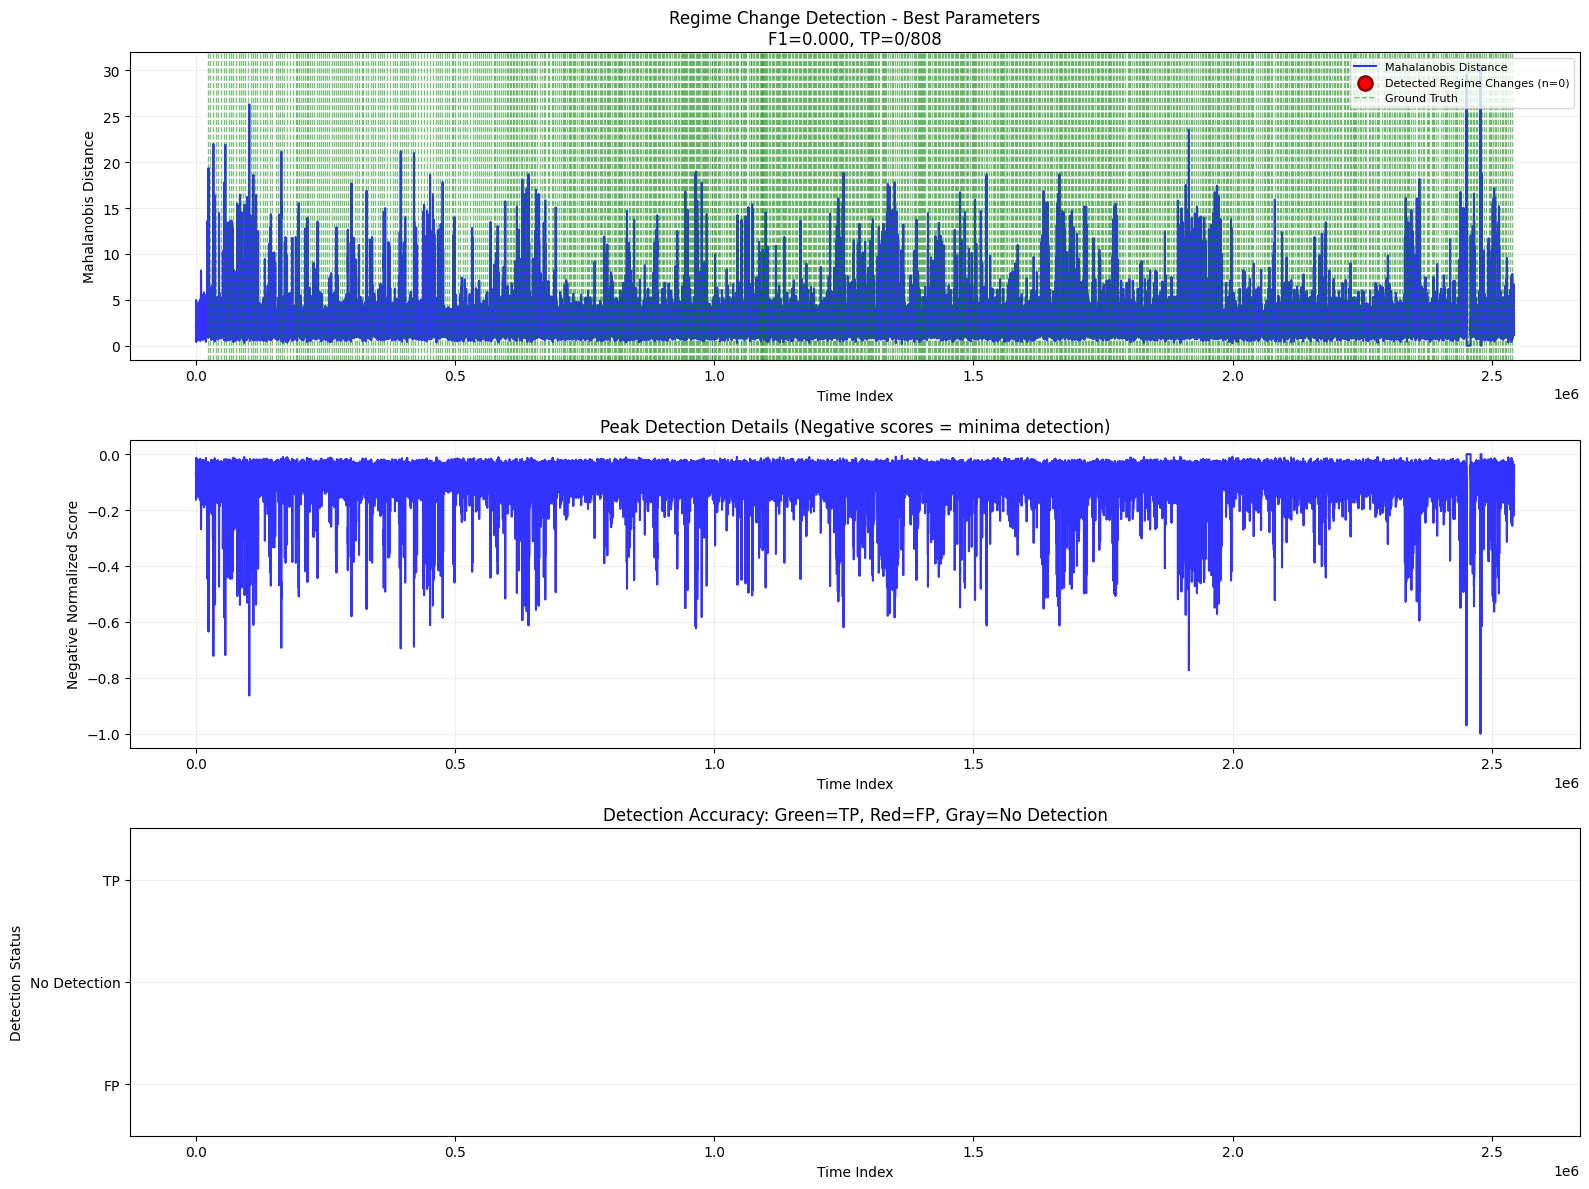


✅ Optimization complete! Results saved to 'bayes_peaks_only/'
   - best_parameters.json
   - results.json
   - best_result_visualization.png


In [35]:
# Bayesian Optimization Pipeline for Regime Change Divergence Detection
# Fixed: STEP=50, WINDOW=100, optimize only find_peaks parameters

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

# ============================================================
# CONFIG
# ============================================================

EVENT_MATCH_THRESHOLD = 50
N_CALLS = 50
N_INITIAL_POINTS = 15
RANDOM_STATE = 42

# FIXED PARAMETERS
FIXED_WINDOW = 100
FIXED_STEP = 50

OUTPUT_DIR = 'bayes_peaks_only'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# DISTANCE METRICS
# ============================================================

def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)

def extract_features(window):
    """
    Extract features from a window of data.
    MODIFY THIS BASED ON YOUR ACTUAL FEATURE EXTRACTION.
    """
    # Placeholder - replace with your actual feature extraction
    features = [
        np.mean(window),
        np.std(window),
        np.median(window),
        np.max(window) - np.min(window),
        np.percentile(window, 25),
        np.percentile(window, 75),
        np.sum(np.abs(np.diff(window))),  # Total variation
        np.mean(np.abs(np.diff(window)))  # Average slope
    ]
    return np.array(features), None

# ============================================================
# EVALUATION
# ============================================================

def evaluate_minima(minima, events):
    """Evaluate detected minima against ground truth events"""
    tp = 0
    fp = 0
    matched_minima = set()

    for ev in events:
        if len(minima) == 0:
            continue
        distances = np.abs(minima - ev)
        idx = np.argmin(distances)
        if distances[idx] <= EVENT_MATCH_THRESHOLD:
            tp += 1
            matched_minima.add(idx)

    for i, peak in enumerate(minima):
        if i not in matched_minima:
            distances = np.abs(events - peak)
            if len(distances) == 0 or np.min(distances) > EVENT_MATCH_THRESHOLD:
                fp += 1

    fn = len(events) - tp

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Score focuses on true positives with small FP penalty
    score = tp - fp * 0.1

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1_score),
        'score': float(score)
    }

# ============================================================
# PRE-COMPUTE MAHALANOBIS SCORES (fixed window/step)
# ============================================================

print(f"\n{'='*60}")
print(f"PRE-COMPUTING MAHALANOBIS SCORES")
print(f"{'='*60}")
print(f"Fixed parameters: WINDOW={FIXED_WINDOW}, STEP={FIXED_STEP}")
print(f"Data length: {len(data)}")
print(f"{'='*60}\n")

# First pass: collect features
all_features = []
feature_timestamps = []

for t in range(FIXED_WINDOW, len(data) - FIXED_WINDOW, FIXED_STEP):
    left_window = data[t-FIXED_WINDOW:t]
    right_window = data[t:t+FIXED_WINDOW]
    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)
    all_features.append(left_feat)
    all_features.append(right_feat)
    feature_timestamps.append(t)

print(f"Collected {len(all_features)} feature vectors")

if len(all_features) == 0:
    raise ValueError("No features extracted! Check your data and window size.")

all_features = np.array(all_features)

# Covariance matrix with regularization
cov = np.cov(all_features.T)
cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)

trace = np.trace(cov)
reg_strength = 1e-6 * trace / max(cov.shape[0], 1) if trace > 0 else 1e-6
cov_reg = cov + np.eye(cov.shape[0]) * reg_strength
cov_inv = pinv(cov_reg)

# Second pass: calculate Mahalanobis scores
timestamps = []
scores_mahal = []

for t in range(FIXED_WINDOW, len(data) - FIXED_WINDOW, FIXED_STEP):
    left_window = data[t-FIXED_WINDOW:t]
    right_window = data[t:t+FIXED_WINDOW]
    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    try:
        s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)
    except:
        s_mahal = np.linalg.norm(left_feat - right_feat)  # Fallback to L2

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

# Normalize scores for better peak detection
scores_norm = (scores_mahal - scores_mahal.min()) / (scores_mahal.max() - scores_mahal.min() + 1e-8)

print(f"Computed {len(scores_mahal)} Mahalanobis scores")
print(f"Score range: [{scores_mahal.min():.3f}, {scores_mahal.max():.3f}]")
print(f"Normalized range: [{scores_norm.min():.3f}, {scores_norm.max():.3f}]")

# ============================================================
# SEARCH SPACE - Only find_peaks parameters
# ============================================================

space = [
    Real(0.01, 2.0, name='prominence'),        # Minimum prominence
    Integer(1, 30, name='distance'),           # Min distance between peaks (samples)
    Integer(1, 15, name='width_min'),          # Minimum width (samples)
    Integer(5, 50, name='width_max'),          # Maximum width (samples)
    Real(0.1, 1.0, name='rel_height'),         # Relative height for width calculation
    Integer(1, 20, name='plateau_min'),        # Minimum plateau size
    Integer(5, 50, name='plateau_max'),        # Maximum plateau size
    Real(0.01, 1.0, name='threshold'),         # Vertical distance to neighbors
    Integer(3, 30, name='wlen')                # Window length for prominence calculation
]

# ============================================================
# GLOBALS
# ============================================================

trial_counter = 0
results = []
evaluated_points = []

# ============================================================
# HEATMAP UPDATE (for prominence vs distance)
# ============================================================

def update_heatmap():
    """Creates 2D heatmap of best parameters"""
    if len(evaluated_points) < 4:
        return

    from scipy.interpolate import griddata

    # Create grid for prominence vs distance
    prom_range = np.linspace(0.01, 2.0, 50)
    dist_range = np.linspace(1, 30, 50)
    P_grid, D_grid = np.meshgrid(prom_range, dist_range)

    points = np.array([[p['prominence'], p['distance']] for p in evaluated_points])
    scores = np.array([p['score'] for p in evaluated_points])

    grid_scores = griddata(points, scores, (P_grid, D_grid), method='linear', fill_value=-1)

    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(grid_scores, extent=[0.01, 2.0, 1, 30],
                   origin='lower', aspect='auto', cmap='viridis', alpha=0.85)

    plt.colorbar(im, ax=ax, label='Score (TP - 0.1*FP)')

    # Plot evaluated points
    ax.scatter(points[:, 0], points[:, 1], c='red', s=60, edgecolors='black', linewidths=1, zorder=5)

    # Highlight best
    best_idx = np.argmax(scores)
    ax.scatter(points[best_idx, 0], points[best_idx, 1],
              c='red', s=300, marker='*', edgecolors='white', linewidths=2, zorder=6)

    ax.set_xlabel('Prominence')
    ax.set_ylabel('Distance')
    ax.set_title(f'Search Progress: Best Score={scores[best_idx]:.1f} ({len(evaluated_points)} trials)')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'current_heatmap.png'), bbox_inches='tight', dpi=150)
    plt.close(fig)

# ============================================================
# OBJECTIVE FUNCTION - Only optimizes find_peaks params
# ============================================================

@use_named_args(space)
def objective(prominence, distance, width_min, width_max, rel_height,
              plateau_min, plateau_max, threshold, wlen):
    global trial_counter

    trial_counter += 1

    print(f'\n{"="*60}')
    print(f'Trial {trial_counter}/{N_CALLS}')
    print(f'  Prominence:    {prominence:.3f}')
    print(f'  Distance:      {distance}')
    print(f'  Width:         ({width_min}, {width_max})')
    print(f'  rel_height:    {rel_height:.2f}')
    print(f'  Plateau:       ({plateau_min}, {plateau_max})')
    print(f'  Threshold:     {threshold:.3f}')
    print(f'  wlen:          {wlen}')
    print(f'{"="*60}')

    # Configure find_peaks parameters
    width_param = None if width_max <= width_min else (width_min, width_max)
    plateau_param = None if plateau_max <= plateau_min else (plateau_min, plateau_max)

    # Use negative of normalized scores to find minima (regime changes)
    # We're looking for troughs in the Mahalanobis distance
    try:
        minima_idx, properties = find_peaks(
            -scores_norm,  # Negative for minima detection
            prominence=prominence,
            distance=distance,
            width=width_param,
            rel_height=rel_height,
            plateau_size=plateau_param,
            threshold=threshold,
            wlen=wlen
        )
    except Exception as e:
        print(f"  Error in find_peaks: {e}")
        minima_idx = []

    # Convert indices to timestamps
    if len(minima_idx) > 0:
        minima_timestamps = timestamps[minima_idx]
    else:
        minima_timestamps = np.array([])

    # Evaluate against ALL events
    metrics = evaluate_minima(minima_timestamps, events)

    print(f'\n  Results:')
    print(f'    Detected peaks: {len(minima_idx)}')
    print(f'    TP={metrics["tp"]}/{len(events)} events')
    print(f'    FP={metrics["fp"]}, FN={metrics["fn"]}')
    print(f'    Precision={metrics["precision"]:.3f}, Recall={metrics["recall"]:.3f}')
    print(f'    F1={metrics["f1_score"]:.3f}, Score={metrics["score"]:.2f}')

    # Store results
    result = {
        'trial': trial_counter,
        'prominence': float(prominence),
        'distance': int(distance),
        'width_min': int(width_min),
        'width_max': int(width_max),
        'rel_height': float(rel_height),
        'plateau_min': int(plateau_min),
        'plateau_max': int(plateau_max),
        'threshold': float(threshold),
        'wlen': int(wlen),
        'n_peaks': len(minima_idx),
        **metrics
    }
    results.append(result)
    evaluated_points.append({
        'trial': trial_counter,
        'prominence': float(prominence),
        'distance': int(distance),
        'score': metrics['score']
    })

    # Save results incrementally
    with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    # Update visualization
    if trial_counter % 5 == 0:  # Update every 5 trials
        update_heatmap()

    # Return negative score for minimization
    return -metrics['score']

# ============================================================
# PLOT BEST RESULT
# ============================================================

def plot_best_result(best_params, timestamps, scores_mahal, scores_norm, minima_timestamps, events):
    """Plot the best result with all events shown"""

    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    # Plot 1: Raw Mahalanobis scores
    ax1 = axes[0]
    ax1.plot(timestamps, scores_mahal, 'b-', linewidth=1.5, alpha=0.8, label='Mahalanobis Distance')
    ax1.scatter(minima_timestamps,
                [scores_mahal[np.where(timestamps == t)[0][0]] for t in minima_timestamps],
                color='red', s=100, zorder=5, marker='o', edgecolors='darkred', linewidth=2,
                label=f'Detected Regime Changes (n={len(minima_timestamps)})')

    # Mark all ground truth events
    for ev in events:
        ax1.axvline(ev, color='green', linestyle='--', alpha=0.5, linewidth=1,
                   label='Ground Truth' if ev == events[0] else '')

    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('Mahalanobis Distance')
    ax1.set_title(f'Regime Change Detection - Best Parameters\nF1={best_params["f1_score"]:.3f}, TP={best_params["tp"]}/{len(events)}')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.2)

    # Plot 2: Normalized scores with plateau detection
    ax2 = axes[1]
    ax2.plot(timestamps, -scores_norm, 'b-', linewidth=1.5, alpha=0.8, label='Negative Normalized Score')

    # Re-run find_peaks with best parameters to get plateau info
    width_param = None if best_params['width_max'] <= best_params['width_min'] else (best_params['width_min'], best_params['width_max'])
    plateau_param = None if best_params['plateau_max'] <= best_params['plateau_min'] else (best_params['plateau_min'], best_params['plateau_max'])

    minima_idx, properties = find_peaks(
        -scores_norm,
        prominence=best_params['prominence'],
        distance=best_params['distance'],
        width=width_param,
        rel_height=best_params['rel_height'],
        plateau_size=plateau_param,
        threshold=best_params['threshold'],
        wlen=best_params['wlen']
    )

    # Mark plateaus
    if 'plateaus' in properties and len(properties['plateaus']) > 0:
        for i, (start, end) in enumerate(properties['plateaus']):
            if start < len(timestamps) and end < len(timestamps):
                ax2.axvspan(timestamps[start], timestamps[end], alpha=0.3, color='orange', label='Plateau' if i == 0 else '')
                ax2.axvline(timestamps[start], color='orange', linestyle=':', alpha=0.8, linewidth=1)
                ax2.axvline(timestamps[end], color='orange', linestyle=':', alpha=0.8, linewidth=1)

    ax2.scatter(timestamps[minima_idx], -scores_norm[minima_idx],
               color='red', s=80, zorder=5, marker='o', edgecolors='darkred', linewidth=1.5)

    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('Negative Normalized Score')
    ax2.set_title('Peak Detection Details (Negative scores = minima detection)')
    ax2.grid(True, alpha=0.2)

    # Plot 3: Detection accuracy visualization
    ax3 = axes[2]

    # Create a binary vector of correct detections
    detection_status = np.zeros(len(timestamps))
    for t in minima_timestamps:
        idx = np.where(timestamps == t)[0]
        if len(idx) > 0:
            # Check if this detection matches any event
            distances = np.abs(events - t)
            if np.min(distances) <= EVENT_MATCH_THRESHOLD:
                detection_status[idx[0]] = 1  # True positive
            else:
                detection_status[idx[0]] = -1  # False positive

    # Plot detection status
    colors = ['red' if x == -1 else 'green' if x == 1 else 'gray' for x in detection_status]
    ax3.bar(timestamps, detection_status, color=colors, alpha=0.6, width=STEP)
    ax3.set_ylim(-1.5, 1.5)
    ax3.set_yticks([-1, 0, 1])
    ax3.set_yticklabels(['FP', 'No Detection', 'TP'])
    ax3.set_xlabel('Time Index')
    ax3.set_ylabel('Detection Status')
    ax3.set_title('Detection Accuracy: Green=TP, Red=FP, Gray=No Detection')
    ax3.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'best_result_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# FINAL ANALYSIS
# ============================================================

def final_analysis():
    """Generate comprehensive final analysis"""

    if len(results) == 0:
        print("No results to analyze")
        return

    # Sort by score
    sorted_results = sorted(results, key=lambda x: x['score'], reverse=True)

    print("\n" + "="*80)
    print("TOP 10 TRIALS")
    print("="*80)

    for i, res in enumerate(sorted_results[:10]):
        print(f"\n{i+1}. Trial {res['trial']}: Score={res['score']:.2f} | "
              f"TP={res['tp']}, FP={res['fp']}, FN={res['fn']} | "
              f"F1={res['f1_score']:.3f}")
        print(f"   Prom={res['prominence']:.3f}, Dist={res['distance']}, "
              f"Width=({res['width_min']},{res['width_max']}), "
              f"Plateau=({res['plateau_min']},{res['plateau_max']})")
        print(f"   RelH={res['rel_height']:.2f}, Thresh={res['threshold']:.3f}, wlen={res['wlen']}")

    # Parameter importance correlation
    print("\n" + "="*80)
    print("PARAMETER CORRELATION WITH SCORE")
    print("="*80)

    param_names = ['prominence', 'distance', 'width_min', 'width_max',
                   'rel_height', 'plateau_min', 'plateau_max', 'threshold', 'wlen']

    for param in param_names:
        if param in results[0]:
            param_vals = np.array([r[param] for r in results])
            scores = np.array([r['score'] for r in results])
            corr = np.corrcoef(param_vals, scores)[0, 1]
            print(f"{param:15}: {corr:+.3f}")

    # Best parameter summary
    best = sorted_results[0]

    print("\n" + "="*80)
    print("BEST PARAMETERS FOUND")
    print("="*80)
    print(f"prominence:     {best['prominence']:.3f}")
    print(f"distance:       {best['distance']}")
    print(f"width:          ({best['width_min']}, {best['width_max']})")
    print(f"rel_height:     {best['rel_height']:.2f}")
    print(f"plateau_size:   ({best['plateau_min']}, {best['plateau_max']})")
    print(f"threshold:      {best['threshold']:.3f}")
    print(f"wlen:           {best['wlen']}")
    print(f"\nPerformance:")
    print(f"  TP: {best['tp']}/{len(events)} events")
    print(f"  FP: {best['fp']}, FN: {best['fn']}")
    print(f"  Precision: {best['precision']:.3f}")
    print(f"  Recall: {best['recall']:.3f}")
    print(f"  F1 Score: {best['f1_score']:.3f}")

    return best

# ============================================================
# RUN OPTIMIZATION
# ============================================================

print(f"\n{'='*60}")
print(f"BAYESIAN OPTIMIZATION - FIND_PEAKS PARAMETERS ONLY")
print(f"{'='*60}")
print(f"Fixed: WINDOW={FIXED_WINDOW}, STEP={FIXED_STEP}")
print(f"Total trials: {N_CALLS}")
print(f"Initial points: {N_INITIAL_POINTS}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"{'='*60}\n")

# Run optimization
optimization_result = gp_minimize(
    objective,
    space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_POINTS,
    random_state=RANDOM_STATE,
    verbose=False
)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

# Final analysis
best_params = final_analysis()

# Save best parameters
with open(os.path.join(OUTPUT_DIR, 'best_parameters.json'), 'w') as f:
    json.dump(best_params, f, indent=2)

# Plot best result
print("\n📊 Generating best result visualization...")

# Get minima with best parameters
width_param = None if best_params['width_max'] <= best_params['width_min'] else (best_params['width_min'], best_params['width_max'])
plateau_param = None if best_params['plateau_max'] <= best_params['plateau_min'] else (best_params['plateau_min'], best_params['plateau_max'])

minima_idx, _ = find_peaks(
    -scores_norm,
    prominence=best_params['prominence'],
    distance=best_params['distance'],
    width=width_param,
    rel_height=best_params['rel_height'],
    plateau_size=plateau_param,
    threshold=best_params['threshold'],
    wlen=best_params['wlen']
)

minima_timestamps = timestamps[minima_idx]

plot_best_result(best_params, timestamps, scores_mahal, scores_norm, minima_timestamps, events)

print(f"\n✅ Optimization complete! Results saved to '{OUTPUT_DIR}/'")
print(f"   - best_parameters.json")
print(f"   - results.json")
print(f"   - best_result_visualization.png")

## tryout what we got

{
  "trial": 1,
  "prominence": 1.5951205438518639,
  "distance": 6,
  "width_min": 12,
  "width_max": 32,
  "rel_height": 0.5012494775682321,
  "plateau_min": 3,
  "plateau_max": 26,
  "threshold": 0.3403715250276317,
  "wlen": 7,
  "n_peaks": 0,
  "tp": 0,
  "fp": 0,
  "fn": 808,
  "precision": 0.0,
  "recall": 0.0,
  "f1_score": 0.0,
  "score": 0.0
}

was:


params = {
    'prominence': np.float64(4.432186659596974),
    'distance': np.int64(5),
    'width': (np.int64(1), None),
    'plateau_size': (1, 5),
    'rel_height': 0.5
}

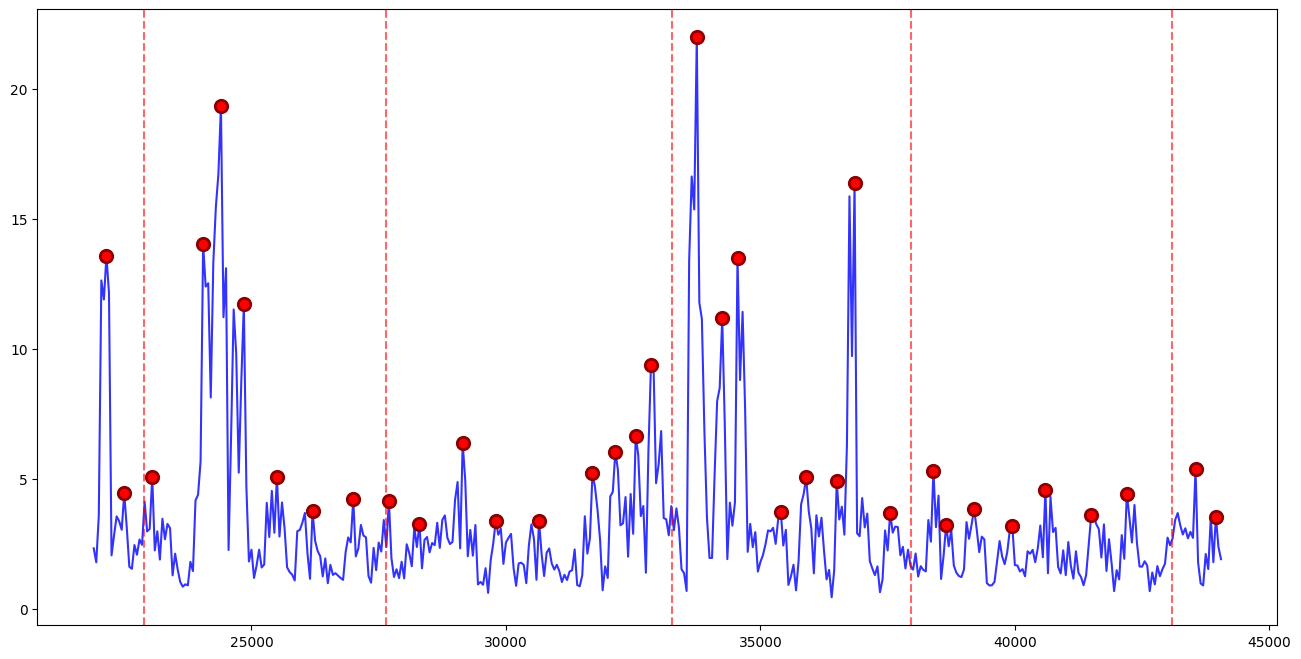

In [44]:

# Your parameters from Bayesian optimization trial
params = {
    'prominence': np.float64(1.5951205438518639),
    'distance': np.int64(5),
    'width': (np.int64(1), None),
    # 'plateau_size': (3, 26),
    'rel_height': 0.5012494775682321,
    # 'threshold': 0.3403715250276317,
    # 'wlen': 7
}

# Filter data around the first 5 events only
mask = (timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)
filtered_timestamps = timestamps[mask]
filtered_scores = scores_mahal[mask]

# Apply find_peaks with ALL parameters
peaks, properties = find_peaks(
    filtered_scores,
    prominence=params['prominence'],
    distance=params['distance'],
    width=params['width'],
    # plateau_size=params['plateau_size'],
    rel_height=params['rel_height'],
    # threshold=params['threshold'],
    # wlen=params['wlen']
)

# ============================================
# PLOTTING
# ============================================

plt.figure(figsize=(16, 8))

# Plot the signal
plt.plot(filtered_timestamps, filtered_scores, 'b-', linewidth=1.5, label='Signal', alpha=0.8)

# Plot vertical lines for first 5 events only
for i, cp in enumerate(events[:5]):
    plt.axvline(cp, color='red', linestyle='--', alpha=0.6, linewidth=1.5,
                label='Ground Truth Event' if i == 0 else '')

# Plot peaks as scatter plot (red dots)
if len(peaks) > 0:
    peak_timestamps = filtered_timestamps[peaks]
    peak_values = filtered_scores[peaks]
    plt.scatter(peak_timestamps, peak_values,
               color='red', s=80, zorder=5,
               edgecolors='darkred', linewidth=2,
               label=f'Detected Peaks (n={len(peaks)})')
else:
    print("⚠️ No peaks detected with these parameters!")

# some stuff deepseek suggested to use (libraries)

## ruptures

In [62]:
import ruptures as rpt
import matplotlib.pyplot as plt
import numpy as np

# Use full dataset - original EEG signal
signal = data
time_axis = timestamps

# Detect change points with PELT on FULL dataset
algo = rpt.Pelt(model="l2").fit(signal)
change_points = algo.predict(pen=np.log(len(signal)) * np.var(signal))

# Create mask for first 5 events window for visualization only
mask = (timestamps < events[4] + 1000) & (timestamps > events[0] - 1000)
filtered_timestamps = timestamps[mask]
filtered_signal = data[mask]

# Filter change points to those within visualization window
visible_change_points = [cp for cp in change_points[:-1]
                        if cp < len(filtered_timestamps)]

# Plot
plt.figure(figsize=(16, 6))
plt.plot(filtered_timestamps, filtered_signal, 'b-', linewidth=1.5, alpha=0.8, label='Original EEG Signal')

for i, cp in enumerate(events[:5]):
    plt.axvline(cp, color='green', linestyle='--', alpha=0.6, linewidth=1.5,
                label='Ground Truth Event' if i == 0 else '')

for i, cp_idx in enumerate(visible_change_points):
    if cp_idx < len(filtered_timestamps):
        plt.axvline(filtered_timestamps[cp_idx], color='red', linestyle='-',
                   alpha=0.7, linewidth=1.5,
                   label=f'Detected Change Point ({len(visible_change_points)} in window)' if i == 0 else '')

plt.title(f'ruptures - EEG Signal: {len(change_points)-1} Total Change Points (Showing {len(visible_change_points)} in first 5 events window)')
plt.xlabel('Timestamps')
plt.ylabel('EEG Amplitude')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print(f"Total change points detected in FULL EEG dataset: {len(change_points)-1}")
print(f"Change point indices: {change_points[:-1]}")
print(f"Change point timestamps (first 10): {[timestamps[cp] for cp in change_points[:10] if cp < len(timestamps)]}")

KeyboardInterrupt: 

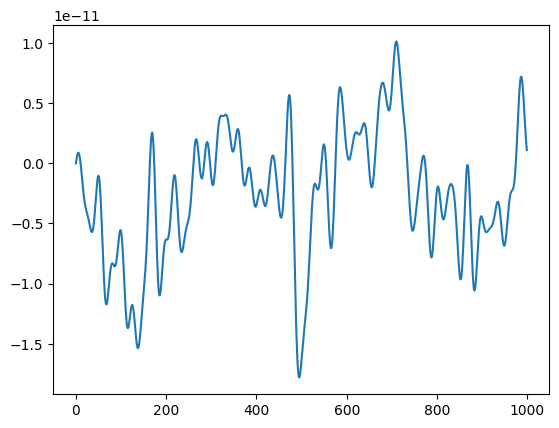

In [64]:
plt.plot(data[:1000])

# lacunarity, deepseek version

In [81]:
true_events = df_behav['fix_cross.started'].dropna().values

channel_name = raw.ch_names[0]
sfreq = raw.info['sfreq']
data, times = raw[channel_name, :]
data = data.flatten()

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform

# ==========================================
# DATA PREPARATION
# ==========================================

# Convert events from seconds to samples (timestamps)
sfreq = 1000  # Sampling frequency in Hz
events_samples = (true_events * sfreq).astype(int)

data = data[:len(data) // 50]

# Create time axis for the data
timestamps = np.arange(len(data))  # Sample indices

print(f"Data shape: {data.shape}")
print(f"Number of events: {len(events_samples)}")
print(f"First 5 events (samples): {events_samples[:5]}")

# ==========================================
# RECURRENCE LACUNARITY FUNCTIONS
# ==========================================

def recurrence_plot(time_series, emb_dim=3, time_delay=1, threshold_ratio=0.1):
    """Create a Recurrence Plot (RP) from a time series."""
    # Phase space reconstruction
    n = len(time_series) - (emb_dim - 1) * time_delay
    if n <= 0:
        raise ValueError("Time series too short for given embedding parameters.")

    trajectory = np.array([time_series[i:i + emb_dim]
                           for i in range(0, n, time_delay)])

    # Calculate distance matrix
    distances = squareform(pdist(trajectory))

    # Create recurrence matrix (binary)
    threshold = threshold_ratio * np.std(distances)
    RP = (distances <= threshold).astype(int)

    return RP

def lacunarity(binary_matrix):
    """Calculate Lacunarity of a binary matrix using box-counting."""
    rows, cols = binary_matrix.shape
    max_box_size = min(rows, cols) // 4

    lacunarity_values = []
    scales = []

    for box_size in range(1, max_box_size + 1, max(1, max_box_size // 15)):
        mass_counts = []
        for i in range(0, rows - box_size + 1, max(1, box_size // 2)):
            for j in range(0, cols - box_size + 1, max(1, box_size // 2)):
                mass = np.sum(binary_matrix[i:i+box_size, j:j+box_size])
                mass_counts.append(mass)

        if not mass_counts:
            continue

        mean_mass = np.mean(mass_counts)
        var_mass = np.var(mass_counts, ddof=1)

        if mean_mass > 0:
            lac = (var_mass / (mean_mass ** 2)) + 1
            lacunarity_values.append(lac)
            scales.append(box_size)

    return np.mean(lacunarity_values), scales, lacunarity_values

def detect_regime_transitions(data, window_size=500, step_size=50,
                              emb_dim=3, time_delay=1, threshold_ratio=0.1):
    """Sliding-window analysis to detect regime transitions."""
    window_centers = []
    lacunarity_over_time = []

    for start in range(0, len(data) - window_size, step_size):
        window = data[start:start + window_size]

        try:
            RP_window = recurrence_plot(window, emb_dim, time_delay, threshold_ratio)
            mean_lac, _, _ = lacunarity(RP_window)

            window_center = start + window_size // 2
            window_centers.append(window_center)
            lacunarity_over_time.append(mean_lac)

        except Exception as e:
            continue

    return np.array(window_centers), np.array(lacunarity_over_time)

Data shape: (50860,)
Number of events: 808
First 5 events (samples): [22891 27639 33271 37953 43085]


In [83]:
window_size = 500  # 500 ms windows (since sfreq=1000)
step_size = 50     # Slide by 50 ms
emb_dim = 3
time_delay = 1
threshold_ratio = 0.1

print("\nComputing recurrence lacunarity...")
window_centers, lac_vals = detect_regime_transitions(data,
                                                      window_size=window_size,
                                                      step_size=step_size,
                                                      emb_dim=emb_dim,
                                                      time_delay=time_delay,
                                                      threshold_ratio=threshold_ratio)

# Smooth the lacunarity values
lac_vals_smoothed = gaussian_filter1d(lac_vals, sigma=2)

# Detect transitions where lacunarity changes rapidly
lac_derivative = np.gradient(lac_vals_smoothed)
transition_threshold = np.std(lac_derivative) * 1.5
transition_indices, _ = find_peaks(np.abs(lac_derivative),
                                    height=transition_threshold,
                                    distance=5)
transition_timestamps = window_centers[transition_indices]

print(f"\nResults:")
print(f"  Total windows analyzed: {len(lac_vals)}")
print(f"  Detected transitions: {len(transition_timestamps)}")


Computing recurrence lacunarity...

Results:
  Total windows analyzed: 1008
  Detected transitions: 37


## plot (first 10s)

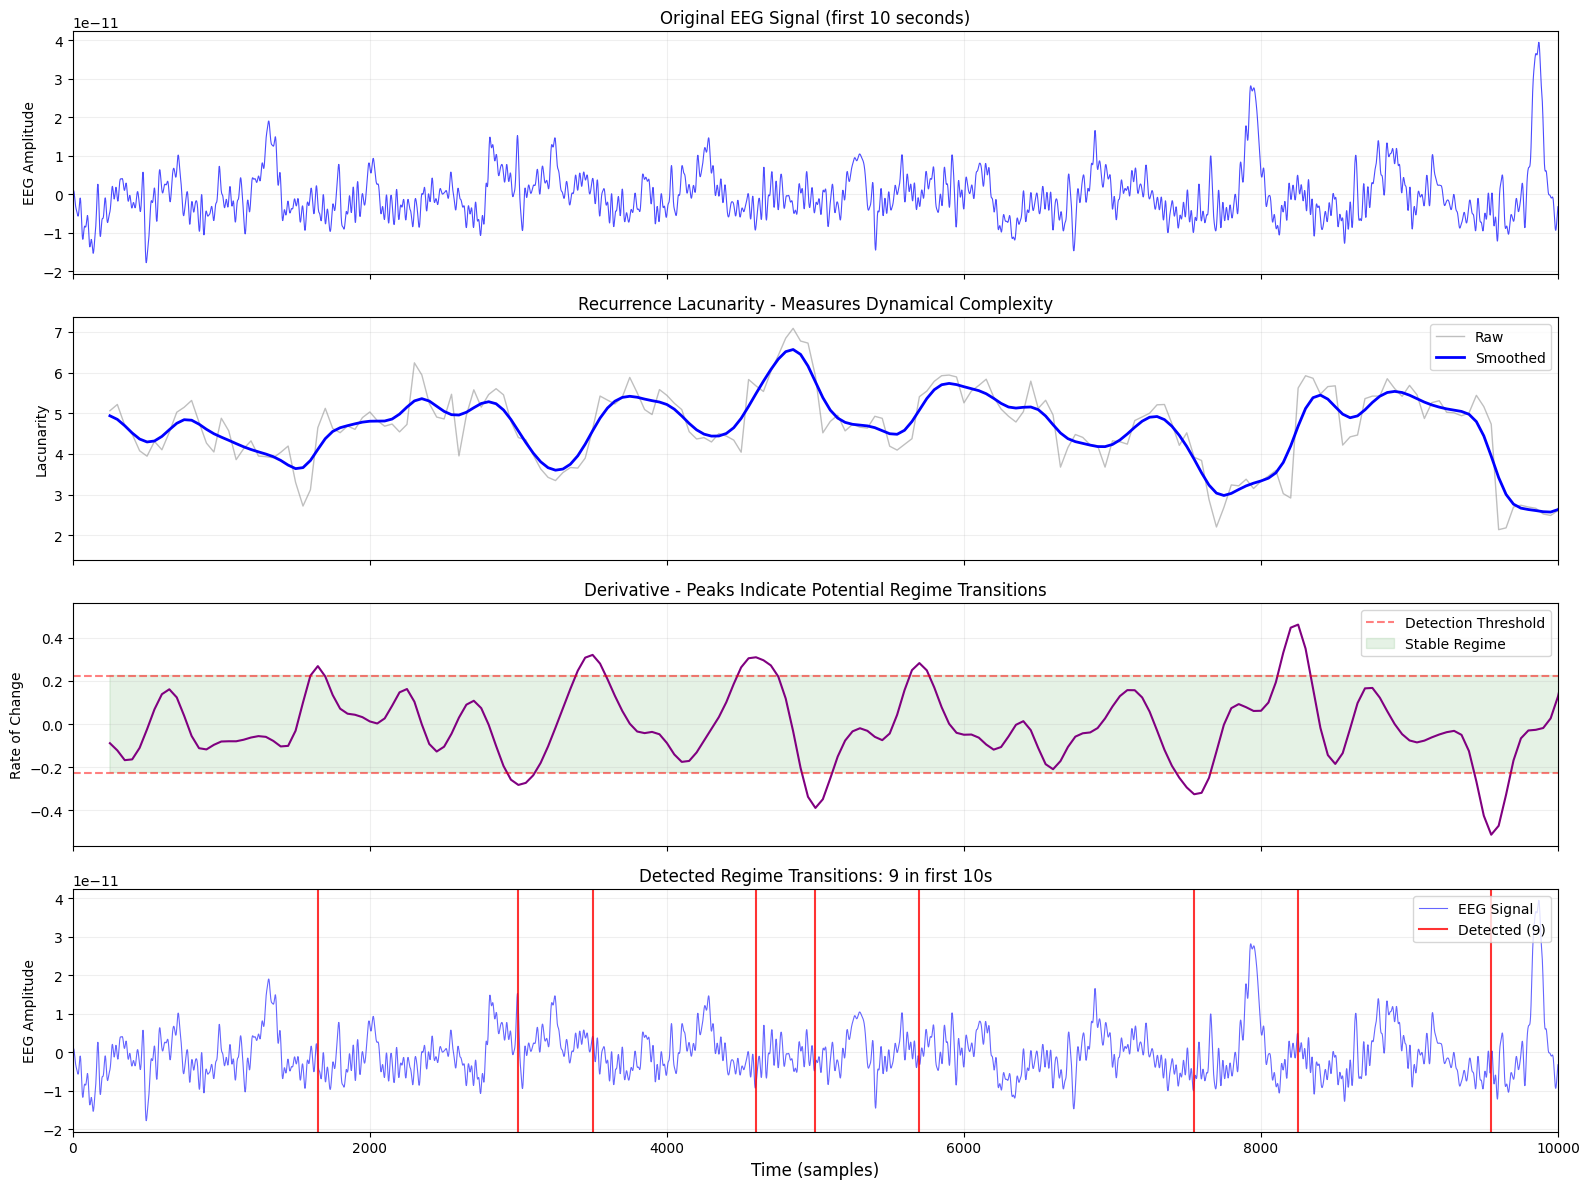


EVALUATION AGAINST GROUND TRUTH EVENTS

In first 10 seconds:
  Ground truth events: 0
  Detected transitions: 9
  True Positives (within 100ms): 0
  False Positives (unmatched detections): 9
  Missed events: 0

Matched events (detection within 100ms):


In [84]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Plot 1: Original EEG Signal (first 10 seconds for visibility)
seconds_to_show = 10
samples_to_show = seconds_to_show * sfreq
axes[0].plot(timestamps[:samples_to_show], data[:samples_to_show],
             'b-', linewidth=0.8, alpha=0.7)
axes[0].set_ylabel('EEG Amplitude')
axes[0].set_title(f'Original EEG Signal (first {seconds_to_show} seconds)', fontsize=12)
axes[0].grid(True, alpha=0.2)

# Plot 2: Recurrence Lacunarity over time
axes[1].plot(window_centers, lac_vals, 'gray', linewidth=1, alpha=0.5, label='Raw')
axes[1].plot(window_centers, lac_vals_smoothed, 'blue', linewidth=2, label='Smoothed')
axes[1].set_ylabel('Lacunarity')
axes[1].set_title('Recurrence Lacunarity - Measures Dynamical Complexity', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.2)

# Plot 3: Derivative of Lacunarity (Change Rate)
axes[2].plot(window_centers, lac_derivative, 'purple', linewidth=1.5)
axes[2].axhline(transition_threshold, color='red', linestyle='--', alpha=0.5,
                label='Detection Threshold')
axes[2].axhline(-transition_threshold, color='red', linestyle='--', alpha=0.5)
axes[2].fill_between(window_centers, transition_threshold, -transition_threshold,
                      alpha=0.1, color='green', label='Stable Regime')
axes[2].set_ylabel('Rate of Change')
axes[2].set_title('Derivative - Peaks Indicate Potential Regime Transitions', fontsize=12)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.2)

# Plot 4: Signal with Detected Transitions (first 10 seconds)
axes[3].plot(timestamps[:samples_to_show], data[:samples_to_show],
             'b-', linewidth=0.8, alpha=0.6, label='EEG Signal')

# Mark ground truth events (within first 10 seconds)
events_in_range = events_samples[events_samples < samples_to_show]
for i, cp in enumerate(events_in_range[:5]):
    axes[3].axvline(cp, color='green', linestyle='--', alpha=0.7, linewidth=1.5,
                    label='Ground Truth Event' if i == 0 else '')

# Mark detected transitions (within first 10 seconds)
visible_transitions = transition_timestamps[transition_timestamps < samples_to_show]
for i, ts in enumerate(visible_transitions[:10]):
    axes[3].axvline(ts, color='red', linestyle='-', alpha=0.8, linewidth=1.5,
                    label=f'Detected ({len(visible_transitions)})' if i == 0 else '')

axes[3].set_xlabel('Time (samples)', fontsize=12)
axes[3].set_ylabel('EEG Amplitude')
axes[3].set_title(f'Detected Regime Transitions: {len(visible_transitions)} in first {seconds_to_show}s', fontsize=12)
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.2)
axes[3].set_xlim(0, samples_to_show)

plt.tight_layout()
plt.show()

# ==========================================
# EVALUATION AGAINST GROUND TRUTH
# ==========================================

print("\n" + "="*70)
print("EVALUATION AGAINST GROUND TRUTH EVENTS")
print("="*70)

# For the first 10 seconds
events_in_range = events_samples[events_samples < samples_to_show]
transitions_in_range = transition_timestamps[transition_timestamps < samples_to_show]

tp = 0
fp = 0
matched = []

for ev in events_in_range:
    distances = np.abs(transitions_in_range - ev)
    if len(distances) > 0:
        min_dist = np.min(distances)
        if min_dist < 100:  # Within 100 ms
            tp += 1
            matched.append((ev, transitions_in_range[np.argmin(distances)], min_dist))
        else:
            fp += 1
    else:
        fp += 1

print(f"\nIn first {seconds_to_show} seconds:")
print(f"  Ground truth events: {len(events_in_range)}")
print(f"  Detected transitions: {len(transitions_in_range)}")
print(f"  True Positives (within 100ms): {tp}")
print(f"  False Positives (unmatched detections): {len(transitions_in_range) - tp}")
print(f"  Missed events: {len(events_in_range) - tp}")

if len(events_in_range) > 0:
    precision = tp / len(transitions_in_range) if len(transitions_in_range) > 0 else 0
    recall = tp / len(events_in_range)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"\n  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1 Score: {f1:.3f}")

print(f"\nMatched events (detection within 100ms):")
for ev, det, dist in matched[:10]:
    print(f"  Truth: {ev:.0f} → Detection: {det:.0f} (diff: {dist:.0f} samples)")

## plot (20-30s)

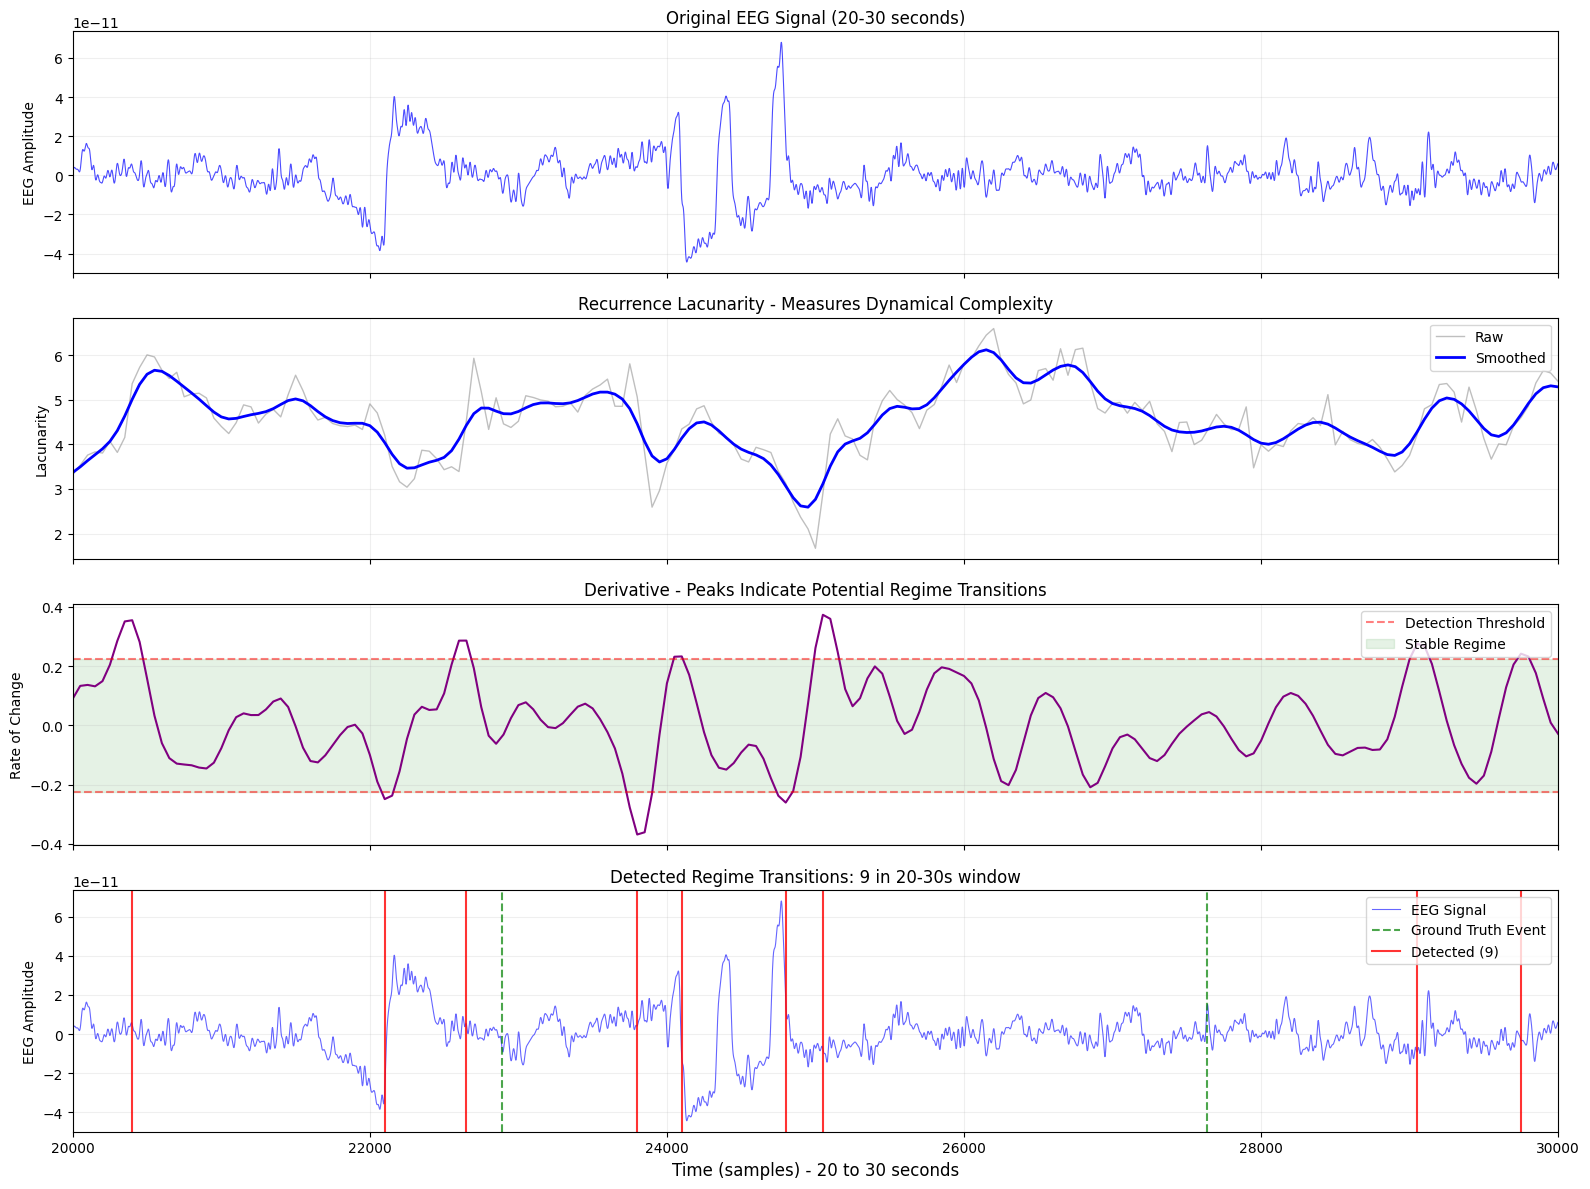


EVALUATION AGAINST GROUND TRUTH EVENTS (20-30 seconds)

In 20-30 second window:
  Ground truth events: 2
  Detected transitions: 9
  True Positives (within 100ms): 0
  False Positives (unmatched detections): 9
  Missed events: 2

  Precision: 0.000
  Recall: 0.000
  F1 Score: 0.000

Matched events (detection within 100ms):


In [85]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Define time range: 20 to 30 seconds
start_second = 20
end_second = 30
start_sample = start_second * sfreq
end_sample = end_second * sfreq

# Plot 1: Original EEG Signal (seconds 20-30)
axes[0].plot(timestamps[start_sample:end_sample], data[start_sample:end_sample],
             'b-', linewidth=0.8, alpha=0.7)
axes[0].set_ylabel('EEG Amplitude')
axes[0].set_title(f'Original EEG Signal ({start_second}-{end_second} seconds)', fontsize=12)
axes[0].grid(True, alpha=0.2)

# Plot 2: Recurrence Lacunarity over time (filtered to range)
mask_lac = (window_centers >= start_sample) & (window_centers <= end_sample)
window_centers_range = window_centers[mask_lac]
lac_vals_range = lac_vals[mask_lac]
lac_vals_smoothed_range = lac_vals_smoothed[mask_lac]
lac_derivative_range = lac_derivative[mask_lac]

axes[1].plot(window_centers_range, lac_vals_range, 'gray', linewidth=1, alpha=0.5, label='Raw')
axes[1].plot(window_centers_range, lac_vals_smoothed_range, 'blue', linewidth=2, label='Smoothed')
axes[1].set_ylabel('Lacunarity')
axes[1].set_title('Recurrence Lacunarity - Measures Dynamical Complexity', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.2)

# Plot 3: Derivative of Lacunarity (Change Rate)
axes[2].plot(window_centers_range, lac_derivative_range, 'purple', linewidth=1.5)
axes[2].axhline(transition_threshold, color='red', linestyle='--', alpha=0.5,
                label='Detection Threshold')
axes[2].axhline(-transition_threshold, color='red', linestyle='--', alpha=0.5)
axes[2].fill_between(window_centers_range, transition_threshold, -transition_threshold,
                      alpha=0.1, color='green', label='Stable Regime')
axes[2].set_ylabel('Rate of Change')
axes[2].set_title('Derivative - Peaks Indicate Potential Regime Transitions', fontsize=12)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.2)

# Plot 4: Signal with Detected Transitions (seconds 20-30)
axes[3].plot(timestamps[start_sample:end_sample], data[start_sample:end_sample],
             'b-', linewidth=0.8, alpha=0.6, label='EEG Signal')

# Mark ground truth events (within 20-30 seconds)
events_in_range = events_samples[(events_samples >= start_sample) & (events_samples <= end_sample)]
for i, cp in enumerate(events_in_range[:5]):
    axes[3].axvline(cp, color='green', linestyle='--', alpha=0.7, linewidth=1.5,
                    label='Ground Truth Event' if i == 0 else '')

# Mark detected transitions (within 20-30 seconds)
visible_transitions = transition_timestamps[(transition_timestamps >= start_sample) &
                                              (transition_timestamps <= end_sample)]
for i, ts in enumerate(visible_transitions[:10]):
    axes[3].axvline(ts, color='red', linestyle='-', alpha=0.8, linewidth=1.5,
                    label=f'Detected ({len(visible_transitions)})' if i == 0 else '')

axes[3].set_xlabel(f'Time (samples) - {start_second} to {end_second} seconds', fontsize=12)
axes[3].set_ylabel('EEG Amplitude')
axes[3].set_title(f'Detected Regime Transitions: {len(visible_transitions)} in {start_second}-{end_second}s window', fontsize=12)
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.2)
axes[3].set_xlim(start_sample, end_sample)

plt.tight_layout()
plt.show()

# ==========================================
# EVALUATION AGAINST GROUND TRUTH
# ==========================================

print("\n" + "="*70)
print(f"EVALUATION AGAINST GROUND TRUTH EVENTS ({start_second}-{end_second} seconds)")
print("="*70)

# For the 20-30 second window
events_in_range = events_samples[(events_samples >= start_sample) & (events_samples <= end_sample)]
transitions_in_range = transition_timestamps[(transition_timestamps >= start_sample) &
                                               (transition_timestamps <= end_sample)]

tp = 0
fp = 0
matched = []

for ev in events_in_range:
    distances = np.abs(transitions_in_range - ev)
    if len(distances) > 0:
        min_dist = np.min(distances)
        if min_dist < 100:  # Within 100 ms
            tp += 1
            matched.append((ev, transitions_in_range[np.argmin(distances)], min_dist))
        else:
            fp += 1
    else:
        fp += 1

print(f"\nIn {start_second}-{end_second} second window:")
print(f"  Ground truth events: {len(events_in_range)}")
print(f"  Detected transitions: {len(transitions_in_range)}")
print(f"  True Positives (within 100ms): {tp}")
print(f"  False Positives (unmatched detections): {len(transitions_in_range) - tp}")
print(f"  Missed events: {len(events_in_range) - tp}")

if len(events_in_range) > 0:
    precision = tp / len(transitions_in_range) if len(transitions_in_range) > 0 else 0
    recall = tp / len(events_in_range)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"\n  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1 Score: {f1:.3f}")

print(f"\nMatched events (detection within 100ms):")
for ev, det, dist in matched[:10]:
    print(f"  Truth: {ev:.0f} → Detection: {det:.0f} (diff: {dist:.0f} samples)")

In [88]:
events[(events > 20000) & (events < 30000)]

array([22891.4514, 27639.975 ])